In [10]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [11]:
query = f"""
    select 
        DISTINCT 
        a.NUMDOCUMENTO as vendor_lead_code,
		a.SEGMICROPEQUENACOMERCIAL,
		a.Proceso,
		a.IMPDHM,
		a.TIPOBASEMICROPEQUENA,
		a.Zona,
		a.AREAEFECTINEGOCIOS,
        DATEADD(DAY, 1, EOMONTH(a.FECHA_ENVIO, -1)) as mes,
		DATEDIFF(
					MONTH,
					DATEADD(DAY, 1, EOMONTH(b.FECHA_ENVIO, -1)),
					DATEADD(DAY, 1, EOMONTH(a.FECHA_ENVIO, -1))
				) as diferencia
    FROM DANTALION.dbo.Base_Maestra_Efectiva_Negocios a 
    left join DANTALION.dbo.Base_Maestra_Efectiva_Negocios b
    on a.NUMDOCUMENTO=b.NUMDOCUMENTO
    WHERE a.NUMDOCUMENTO IS NOT NULL
    and a.fecha_envio >='2026-01-01'
	and DATEDIFF(
					MONTH,
					DATEADD(DAY, 1, EOMONTH(b.FECHA_ENVIO, -1)),
					DATEADD(DAY, 1, EOMONTH(a.FECHA_ENVIO, -1))
				) <= 3
"""
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [12]:
df_base.groupBy('mes') \
    .count() \
    .orderBy('mes') \
    .show(30)


+----------+------+
|       mes| count|
+----------+------+
|2026-01-01|576220|
|2026-02-01|496680|
|2026-03-01|547183|
|2026-04-01|499151|
|2026-05-01|446784|
|2026-06-01|554975|
|2026-07-01|493189|
|2026-08-01|429306|
+----------+------+



In [13]:

window_spec = Window.partitionBy("mes","vendor_lead_code").orderBy(F.col('vendor_lead_code').asc_nulls_last())
df_base = df_base.withColumn("ref1_vici", row_number().over(window_spec))
df_base = df_base.filter(F.col('ref1_vici')==1).drop('ref1_vici')    
df_base.groupBy('mes') \
    .count() \
    .orderBy('mes') \
    .show(30)


+----------+------+
|       mes| count|
+----------+------+
|2026-01-01|118787|
|2026-02-01| 80400|
|2026-03-01| 99656|
|2026-04-01| 89776|
|2026-05-01| 85980|
|2026-06-01|147825|
|2026-07-01|146278|
|2026-08-01|148486|
+----------+------+



In [24]:
df_base.dropDuplicates(['vendor_lead_code']).groupBy('mes') \
    .count() \
    .orderBy('mes') \
    .show(30)

+----------+-----+
|       mes|count|
+----------+-----+
|2026-01-01|31537|
|2026-02-01|23028|
|2026-03-01|20398|
|2026-04-01|20678|
|2026-05-01|15489|
|2026-06-01|27789|
|2026-07-01|20102|
|2026-08-01|10560|
+----------+-----+



In [4]:
print([row['TEA' ] for row in df_base.select('TEA').distinct().collect()])


['0.1255', '0.55', '0.32', '0.22900000', '0.59900000', '0.349', '0.299', '0.60', '0.279', '0.569', '0.24900000', '0.57', '0.25', '0.169', '0.30', '0', '0.419', '0.794', '0.41900000', '0.00000000', '0.09900000', '0.27900000', '0.21', '0.15', '0.79400000', '0.35', '0.39', '0.8791', '0.42', '0.71', '0.79', '0.16900000', '0.89', '0.399', '0.53', '0.14900000', '0.459', '0.52900000', '0.10', '0.33900000', '0.389', '0.65900000', '0.52', '0.54900000', '0.189', '0.40', '0.62', '0.38900000', '0.37', '0.50', '0.499', '0.439', '0.39900000', '0.599', '0.31900000', '0.47900000', '0.34', '0.66', '0.48', '0.61900000', '0.659', '0.709', '0.149', '0.209', '0.56900000', '0.34900000', '0.70900000', '0.28', '0.229', '0.249', '0.23', '0.479', '0.319', '0.29900000', '0.45900000', '0.8364', '0.17', '0.369', '0.339', '0.519', '0.099', '0.36900000', '0.549', '0.51900000', '0.46', '0.619', '0.20900000', '0.44', '0.49900000', '0.25900000', '0.529', '0.43900000', '0.259', '109.83', '1.0186', None]


In [ ]:
['0.1255', '0.55', '0.32', '0.22900000', '0.59900000', '0.349', '0.299', '0.60', '0.279', '0.569', '0.24900000', '0.57', '0.25', '0.169', '0.30', '0', '0.419', '0.794', '0.41900000', '0.00000000', '0.09900000', '0.27900000', '0.21', '0.15', '0.79400000', '0.35', '0.39', '0.8791', '0.42', '0.71', '0.79', '0.16900000', '0.89', '0.399', '0.53', '0.14900000', '0.459', '0.52900000', '0.10', '0.33900000', '0.389', '0.65900000', '0.52', '0.54900000', '0.189', '0.40', '0.62', '0.38900000', '0.37', '0.50', '0.499', '0.439', '0.39900000', '0.599', '0.31900000', '0.47900000', '0.34', '0.66', '0.48', '0.61900000', '0.659', '0.709', '0.149', '0.209', '0.56900000', '0.34900000', '0.70900000', '0.28', '0.229', '0.249', '0.23', '0.479', '0.319', '0.29900000', '0.45900000', '0.8364', '0.17', '0.369', '0.339', '0.519', '0.099', '0.36900000', '0.549', '0.51900000', '0.46', '0.619', '0.20900000', '0.44', '0.49900000', '0.25900000', '0.529', '0.43900000', '0.259', '109.83', '1.0186', None]

In [4]:
print([row['IMPDHM' ] for row in df_base.select('IMPDHM').distinct().collect()])


['15389.96', '24773.16', '40074.51', '12236.76', '244958.83', '126888.66', '39349.22', '2041.37', '64013.16', '8933.40', '6054.00', '23321.88', '155156.38', '60512.98', '20005.05', '37955.69', '10279.53', '9583', '2100.95', '3103.00', '54611.32', '8318.97', '19786.33', '1560.00', '20533.65', '23602.66', '25349.87', '33830.10', '93955.05', '140513.16', '7828.48', '13101.47', '5867.92', '63025.88', '161134.32', '19785.96', '45600.59', '7969.18', '258669.59', '55108.44', '33582.65', '2215.42', '111864.35', '7038.57', '20330.99', '93773.92', '3539.18', '11226.61', '10132.08', '23075.39', '52754.37', '3053.01', '19193.34', '200328.07', '3077.73', '5179.64', '222631', '15257.58', '73365.50', '123964.57', '18900.34', '11311.31', '112351.09', '9605.45', '14285.67', '2641.72', '3741.86', '844.79', '11900.00', '16316.94', '1951.11', '12686.13', '16551.86', '43143.46', '248106.72', '12107.70', '12129.26', '2628.27', '47844.10', '26421.57', '4099.47', '61094.34', '27107.71', '10091.5', '50412.92',

In [14]:
from pyspark.sql import functions as F

df_base = (
    df_base
    .withColumn(
        "IMPDHM",
        F.col("IMPDHM").cast("double")
    )
    .withColumn(
        "RANGO_IMPDHM",
        F.when(F.col("IMPDHM").isNull(), "00. SIN DATOS")
         .when(F.col("IMPDHM") < 5000, "01. [0 - 5 mil)")
         .when(F.col("IMPDHM") < 10000, "02. [5 - 10 mil)")
         .when(F.col("IMPDHM") < 20000, "03. [10 - 20 mil)")
         .when(F.col("IMPDHM") < 30000, "04. [20 - 30 mil)")
         .when(F.col("IMPDHM") < 50000, "05. [30 - 50 mil)")
         .when(F.col("IMPDHM") < 75000, "06. [50 - 75 mil)")
         .when(F.col("IMPDHM") < 100000, "07. [75 - 100 mil)")
         .when(F.col("IMPDHM") < 150000, "08. [100 - 150 mil)")
         .when(F.col("IMPDHM") < 200000, "09. [150 - 200 mil)")
         .otherwise("10. >= 200 mil")
    )
)

In [15]:
df_base=df_base.withColumn('diferencia',when(F.col('diferencia').between(1,3),F.col('diferencia')).otherwise(F.lit('0')))


In [8]:
df_base.show(2)

+----------------+------------------------+-------------+-------+--------------------+----+------------------+----------+----------+-----------------+
|vendor_lead_code|SEGMICROPEQUENACOMERCIAL|      Proceso| IMPDHM|TIPOBASEMICROPEQUENA|Zona|AREAEFECTINEGOCIOS|       mes|diferencia|     RANGO_IMPDHM|
+----------------+------------------------+-------------+-------+--------------------+----+------------------+----------+----------+-----------------+
|        00012927|                     PRF|HUMANO SEGURO|20000.0|                 X06|   1|               SJM|2026-01-01|         3|04. [20 - 30 mil)|
|        00016562|                     ELT|         FULL|   NULL|                NULL|   1|               ICA|2026-01-01|         0|    00. SIN DATOS|
+----------------+------------------------+-------------+-------+--------------------+----+------------------+----------+----------+-----------------+
only showing top 2 rows


In [16]:
print(df_base.columns)

['vendor_lead_code', 'SEGMICROPEQUENACOMERCIAL', 'Proceso', 'IMPDHM', 'TIPOBASEMICROPEQUENA', 'Zona', 'AREAEFECTINEGOCIOS', 'mes', 'diferencia', 'RANGO_IMPDHM']


In [31]:
from pyspark.sql import functions as F

df_resumen = (
    df_base
    .groupBy('producto',"mes",'PROPENSION', "diferencia")
    .agg(
        F.count("vendor_lead_code").alias("cantidad")
    )
    .orderBy("mes", "diferencia")
)

# df_resumen.show(100, False)


In [17]:
from pyspark.sql import functions as F

df_resumen = (
    df_base
    .groupBy('mes','SEGMICROPEQUENACOMERCIAL',"Proceso",'TIPOBASEMICROPEQUENA','Zona','AREAEFECTINEGOCIOS', "diferencia")
    .agg(
        F.count("vendor_lead_code").alias("cantidad")
    )
    .orderBy("Proceso", "diferencia")
)

df_resumen_2 = (
    df_base
    .groupBy('mes','SEGMICROPEQUENACOMERCIAL',"Proceso",'TIPOBASEMICROPEQUENA','Zona','AREAEFECTINEGOCIOS', "diferencia")
    .agg(
        F.count("IMPDHM").alias("IMPDHM_count"),
        F.sum("IMPDHM").alias("IMPDHM_sum")
    )
    .orderBy("Proceso", "IMPDHM_sum")
)

# df_resumen=df_resumen.join(df_resumen_1,['mes','SEGMICROPEQUENACOMERCIAL',"Proceso",'TIPOBASEMICROPEQUENA','Zona','AREAEFECTINEGOCIOS', "diferencia"],'left')
df_resumen=df_resumen.join(df_resumen_2,['mes','SEGMICROPEQUENACOMERCIAL',"Proceso",'TIPOBASEMICROPEQUENA','Zona','AREAEFECTINEGOCIOS', "diferencia"],'left')


df_resumen = df_resumen.withColumn(
    "ref",
    F.add_months(
        F.col("mes"),
        -F.col("diferencia")
    )
)

In [16]:
df_base = (
    df_base
    .withColumn(
        "LINEA_SAE",
        F.when(F.col("LINEA_SAE").isNull(), None)
         .otherwise(F.col("LINEA_SAE"))
    )
    .withColumn(
        "TEA",
        F.when(F.col("TEA").isNull(), None)
         .otherwise(F.col("TEA"))
    )
)

In [32]:
from pyspark.sql import functions as F

columnas_grupo = [
    "producto",
    "mes",
    "PROPENSION",
    "diferencia"
]

df_resumen = (
    df_base
    .groupBy(*columnas_grupo)
    .agg(
        # Cantidad general de registros
        F.count("vendor_lead_code").alias("cantidad"),

        # TEA
        F.count("TEA").alias("tea_count"),
        F.sum("TEA").alias("tea_sum"),

        # Línea SAE
        F.count("LINEA_SAE").alias("linea_sae_count"),
        F.sum("LINEA_SAE").alias("linea_sae_sum")
    )
    .withColumn(
        "ref",
        F.add_months(
            F.col("mes"),
            -F.col("diferencia").cast("int")
        )
    )
    .orderBy(
        "producto",
        "mes",
        "PROPENSION",
        "diferencia"
    )
)   

In [33]:
df_resumen = df_resumen.withColumn(
    "ref",
    F.add_months(
        F.col("mes"),
        -F.col("diferencia")
    )
)

In [39]:
from pyspark.sql import functions as F

df_resumen=df_resumen.filter(
        ~((F.col("producto") == "EC Cliente")&
        (F.col("PROPENSION") == '3'))
    )

In [18]:
df_filtrado = df_resumen.toPandas()


In [19]:
df_filtrado.head()

,mes,SEGMICROPEQUENACOMERCIAL,Proceso,TIPOBASEMICROPEQUENA,Zona,AREAEFECTINEGOCIOS,diferencia,cantidad,IMPDHM_count,IMPDHM_sum,ref
0,2026-01-01,ELT,FASTTRACK,X10,1,TARAPOTO,2,19,19.0,1776632.37,2025-11-01
1,2026-01-01,ELT,FASTTRACK,X06,1,CHICLAYO,1,19,20.0,176912.80,2025-12-01
2,2026-01-01,PRF,FASTTRACK,X06,1,LAMBAYEQUE,0,93,93.0,1696313.08,2026-01-01
3,2026-01-01,ELT,HUMANO SEGURO,X06,2,ICA,0,23,23.0,230620.88,2026-01-01
4,2026-01-01,PRF,FASTTRACK,X10,3,CUSCO,2,27,27.0,1784923.63,2025-11-01


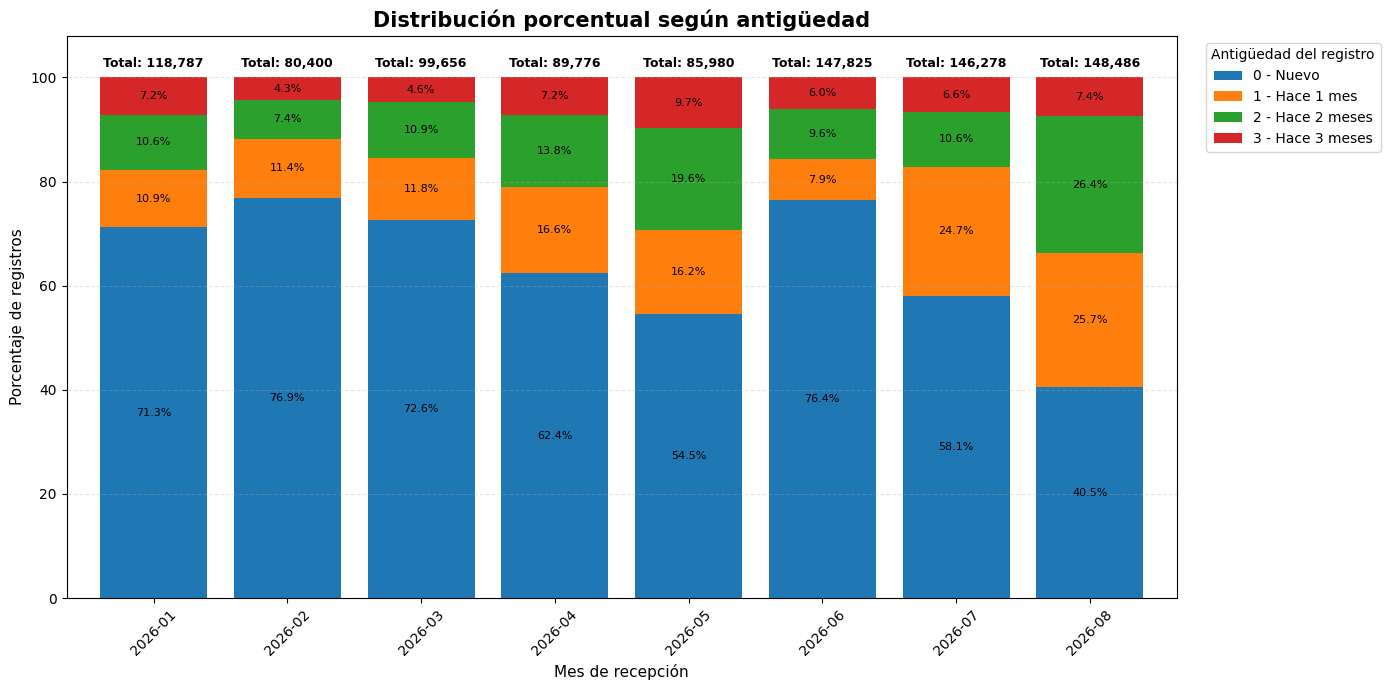

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,71.25%,10.94%,10.64%,7.16%,118787
2026-02-01,76.87%,11.38%,7.44%,4.31%,80400
2026-03-01,72.59%,11.85%,10.91%,4.64%,99656
2026-04-01,62.41%,16.59%,13.76%,7.24%,89776
2026-05-01,54.51%,16.22%,19.59%,9.68%,85980
2026-06-01,76.43%,7.92%,9.65%,6.00%,147825
2026-07-01,58.05%,24.73%,10.62%,6.60%,146278
2026-08-01,40.46%,25.74%,26.40%,7.40%,148486


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["diferencia"] = pd.to_numeric(
    df_grafico["diferencia"],
    errors="coerce"
)

# Eliminar registros sin mes o diferencia
df_grafico = df_grafico.dropna(
    subset=["mes", "diferencia"]
)

# Convertir diferencia a entero
df_grafico["diferencia"] = (
    df_grafico["diferencia"]
    .astype(int)
)

# ============================================================
# CREAR ETIQUETA DE ANTIGÜEDAD
# ============================================================
def crear_etiqueta_diferencia(valor):
    if valor == 0:
        return "0 - Nuevo"
    elif valor == 1:
        return "1 - Hace 1 mes"
    else:
        return f"{valor} - Hace {valor} meses"


df_grafico["antiguedad"] = (
    df_grafico["diferencia"]
    .apply(crear_etiqueta_diferencia)
)

# ============================================================
# RESUMEN POR MES Y DIFERENCIA
# ============================================================
df_diferencia = (
    df_grafico
    .groupby(
        ["mes", "diferencia", "antiguedad"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Orden correcto de las categorías
orden_antiguedad = (
    df_diferencia[
        ["diferencia", "antiguedad"]
    ]
    .drop_duplicates()
    .sort_values("diferencia")["antiguedad"]
    .tolist()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_diferencia_cantidad = (
    df_diferencia
    .pivot(
        index="mes",
        columns="antiguedad",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Mantener el orden: nuevo, 1 mes, 2 meses...
columnas_existentes = [
    columna
    for columna in orden_antiguedad
    if columna in df_diferencia_cantidad.columns
]

df_diferencia_cantidad = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
)

# ============================================================
# TOTAL DE LA BASE POR MES
# ============================================================
df_diferencia_cantidad["Total base"] = (
    df_diferencia_cantidad.sum(axis=1)
)

# ============================================================
# TABLA EN PORCENTAJES
# ============================================================
df_diferencia_porcentaje = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
    .div(
        df_diferencia_cantidad["Total base"],
        axis=0
    )
    * 100
)

# Añadir total de la base como cantidad
df_diferencia_porcentaje["Total base"] = (
    df_diferencia_cantidad["Total base"]
)

# ============================================================
# GRÁFICO DE BARRAS APILADAS AL 100%
# ============================================================
ax = df_diferencia_porcentaje[
    columnas_existentes
].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.80
)

# ============================================================
# ETIQUETAS DE PORCENTAJE DENTRO DE LAS BARRAS
# ============================================================
for contenedor in ax.containers:

    etiquetas = []

    for barra in contenedor:
        valor = barra.get_height()

        if valor >= 2:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# ============================================================
# TOTAL DE LA BASE ENCIMA DE CADA BARRA
# ============================================================
for posicion, total in enumerate(
    df_diferencia_porcentaje["Total base"]
):
    ax.text(
        posicion,
        101.5,
        f"Total: {total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# FORMATO DEL GRÁFICO
# ============================================================
plt.title(
    f"Distribución porcentual según antigüedad",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mes de recepción",
    fontsize=11
)

plt.ylabel(
    "Porcentaje de registros",
    fontsize=11
)

plt.xticks(
    range(len(df_diferencia_porcentaje.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_diferencia_porcentaje.index
    ],
    rotation=45
)

plt.ylim(0, 108)

plt.legend(
    title="Antigüedad del registro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA FINAL PARA MOSTRAR
# ============================================================
df_tabla_final = (
    df_diferencia_porcentaje
    .copy()
)

# Dar formato de porcentaje a las columnas de antigüedad
for columna in columnas_existentes:
    df_tabla_final[columna] = (
        df_tabla_final[columna]
        .map(lambda x: f"{x:.2f}%")
    )

# Total base como entero
df_tabla_final["Total base"] = (
    df_tabla_final["Total base"]
    .astype(int)
)

display(df_tabla_final)

In [27]:
df_filtrado["Proceso"] = df_filtrado["Proceso"].replace({
    "FasTrack": "FASTTRACK"
})

In [28]:
df_filtrado['Proceso'].unique()

array(['FASTTRACK', 'HUMANO SEGURO', 'FULL', 'ERROR', None], dtype=object)

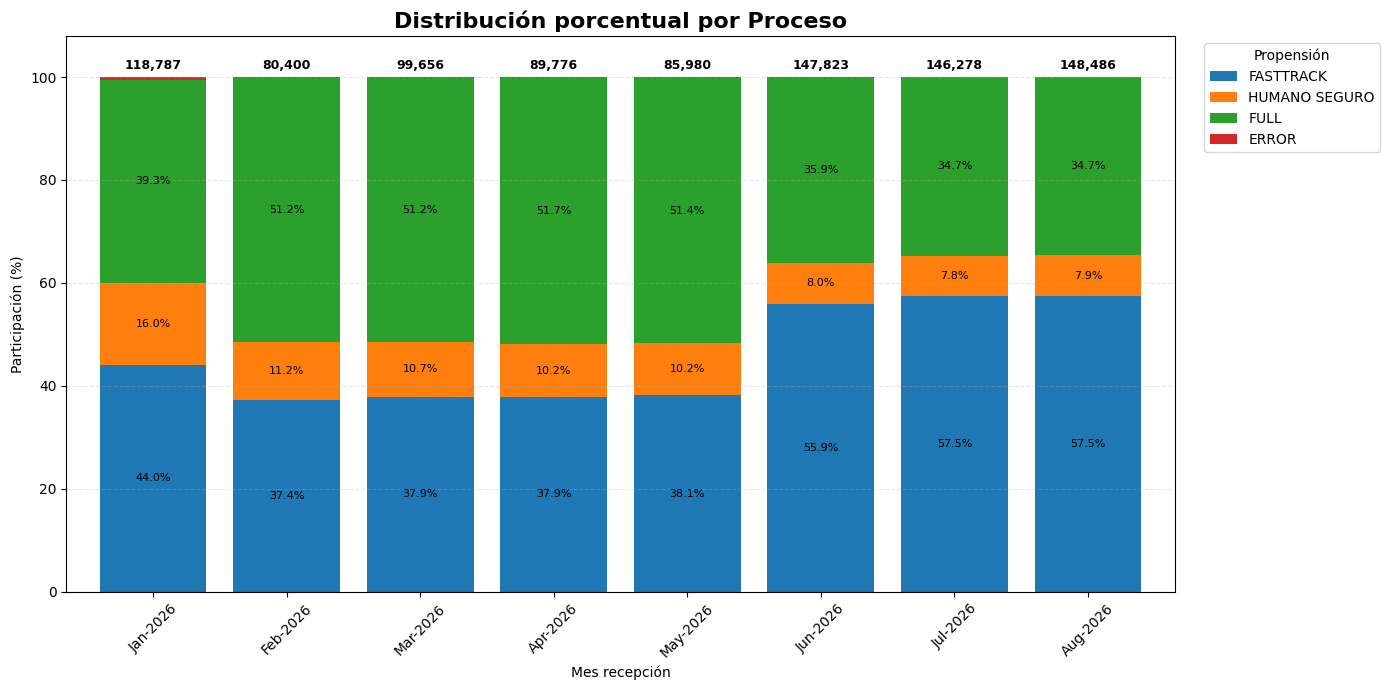

Proceso,FASTTRACK,HUMANO SEGURO,FULL,ERROR,Total Base
mes,,,,,
2026-01-01,44.05%,16.03%,39.33%,0.60%,118787
2026-02-01,37.35%,11.23%,51.15%,0.27%,80400
2026-03-01,37.90%,10.68%,51.15%,0.27%,99656
2026-04-01,37.86%,10.20%,51.73%,0.20%,89776
2026-05-01,38.15%,10.19%,51.39%,0.28%,85980
2026-06-01,55.94%,8.02%,35.91%,0.13%,147823
2026-07-01,57.47%,7.84%,34.69%,0.00%,146278
2026-08-01,57.48%,7.86%,34.66%,0.00%,148486


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["Proceso"] = (
    df_grafico["Proceso"]
    .fillna("SIN Proceso")
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","Proceso"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "FASTTRACK",
    "HUMANO SEGURO",
    "FULL",
    "ERROR",
    "SIN Proceso"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"Distribución porcentual por Proceso",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

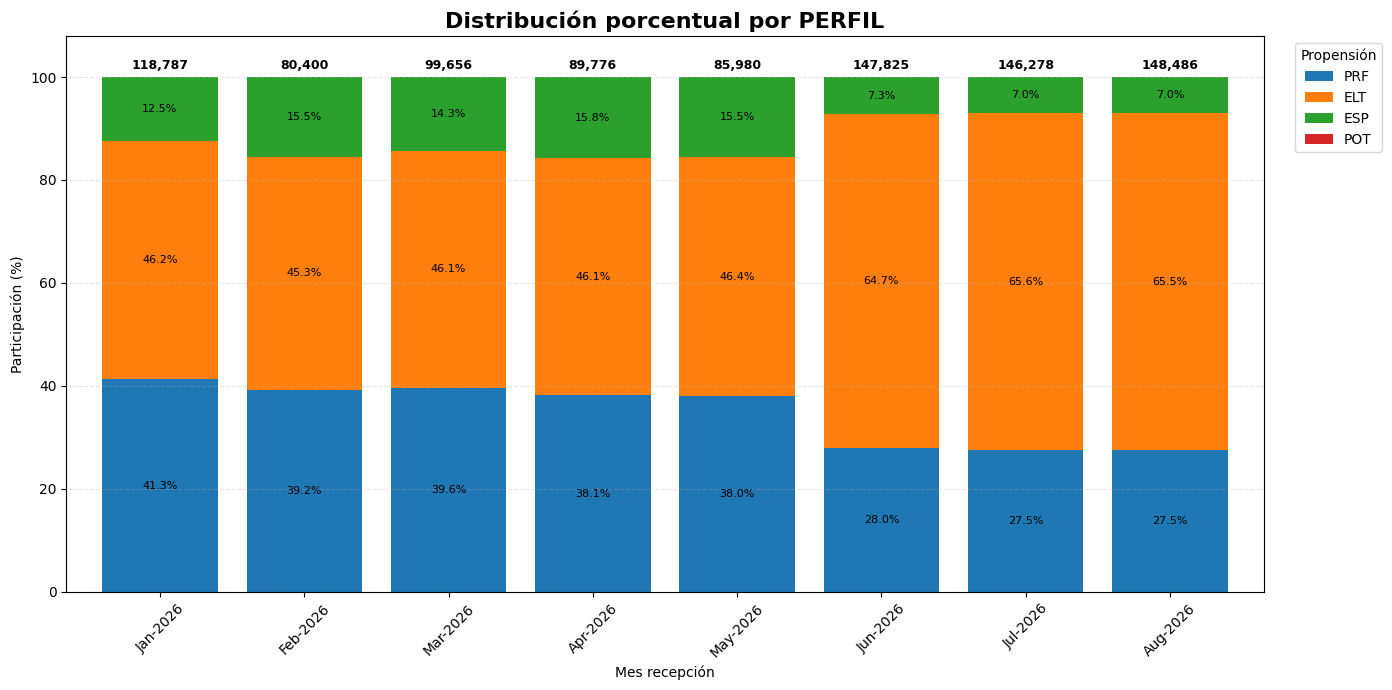

SEGMICROPEQUENACOMERCIAL,PRF,ELT,ESP,POT,Total Base
mes,,,,,
2026-01-01,41.26%,46.22%,12.52%,0.00%,118787
2026-02-01,39.20%,45.29%,15.50%,0.00%,80400
2026-03-01,39.56%,46.13%,14.31%,0.00%,99656
2026-04-01,38.14%,46.10%,15.76%,0.00%,89776
2026-05-01,38.04%,46.42%,15.55%,0.00%,85980
2026-06-01,28.01%,64.73%,7.26%,0.00%,147825
2026-07-01,27.48%,65.55%,6.96%,0.00%,146278
2026-08-01,27.51%,65.49%,6.99%,0.00%,148486


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["SEGMICROPEQUENACOMERCIAL"] = (
    df_grafico["SEGMICROPEQUENACOMERCIAL"]
    .fillna("SIN SEGMICROPEQUENACOMERCIAL")
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","SEGMICROPEQUENACOMERCIAL"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "PRF",
    "ELT",
    "ESP",
    "POT",
    "SIN SEGMICROPEQUENACOMERCIAL"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"Distribución porcentual por PERFIL",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

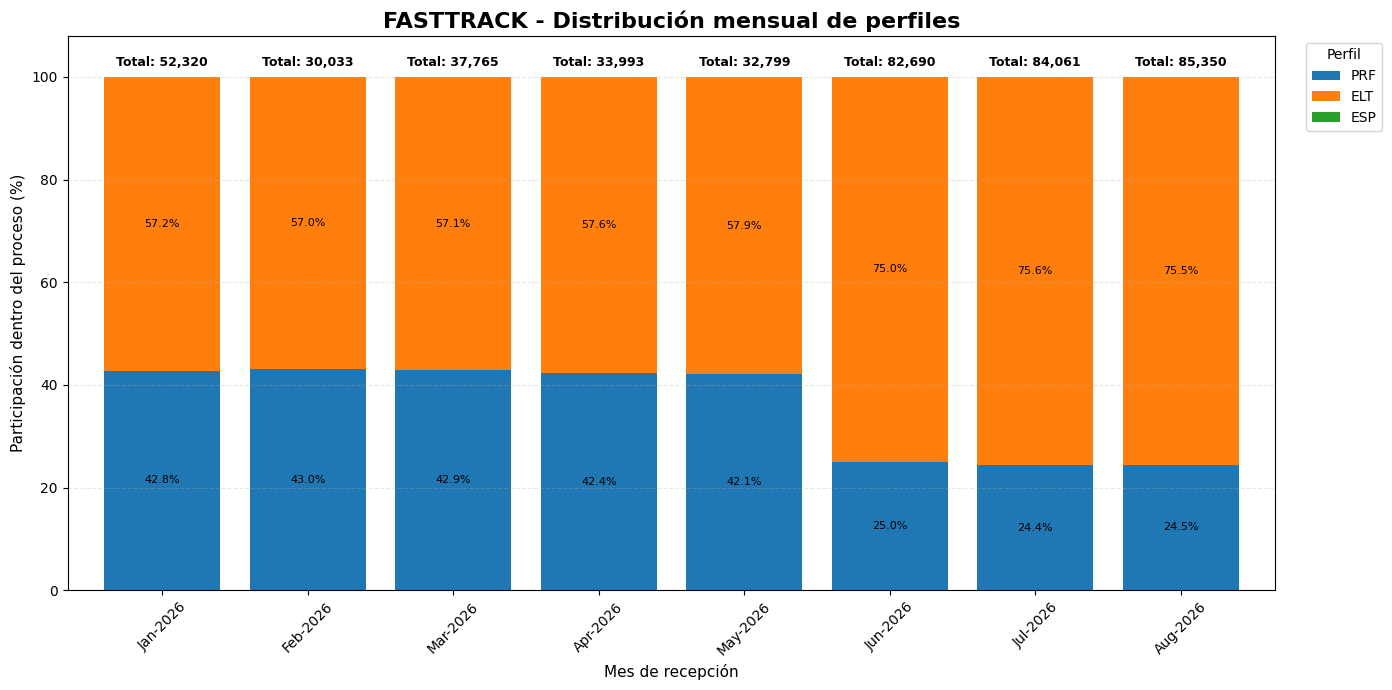

Tabla del proceso: FASTTRACK


SEGMICROPEQUENACOMERCIAL,PRF,ELT,ESP,Total Proceso
mes,,,,
2026-01-01,42.78%,57.22%,0.00%,52320
2026-02-01,43.02%,56.98%,0.00%,30033
2026-03-01,42.86%,57.14%,0.00%,37765
2026-04-01,42.38%,57.62%,0.00%,33993
2026-05-01,42.11%,57.89%,0.00%,32799
2026-06-01,24.99%,75.01%,0.00%,82690
2026-07-01,24.41%,75.59%,0.00%,84061
2026-08-01,24.48%,75.52%,0.00%,85350


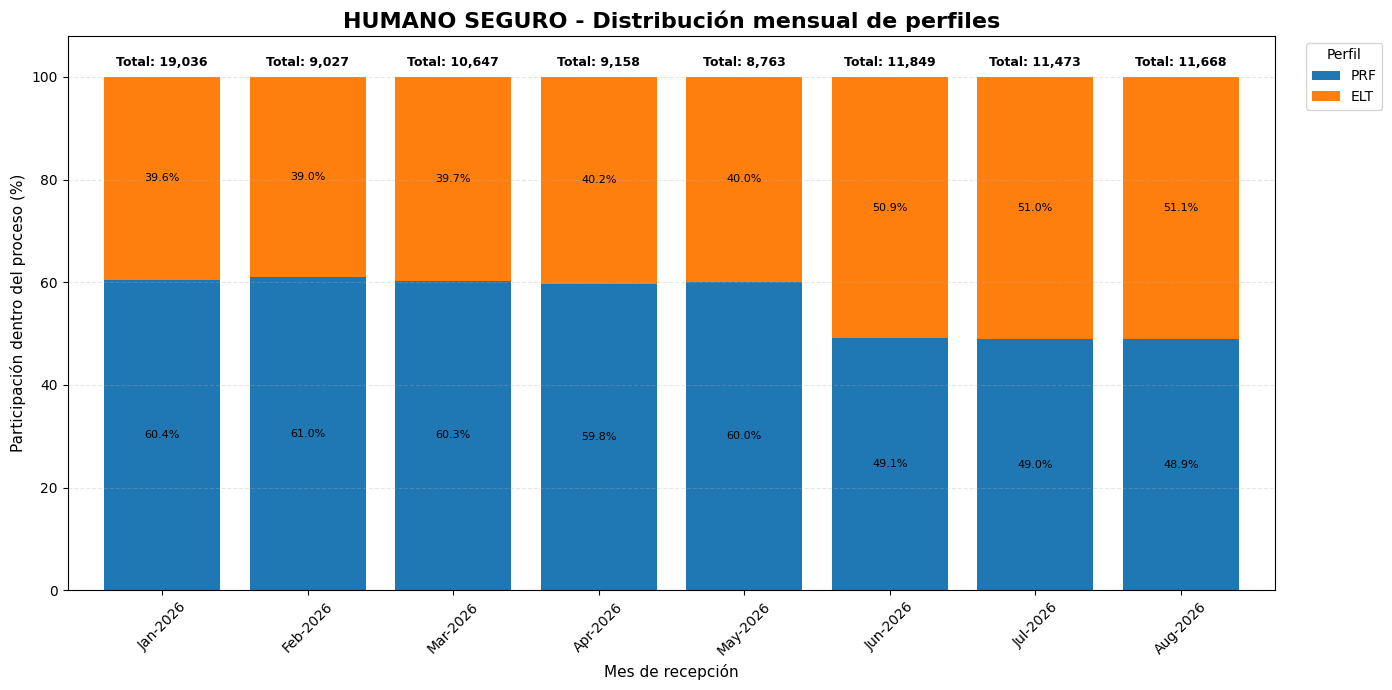

Tabla del proceso: HUMANO SEGURO


SEGMICROPEQUENACOMERCIAL,PRF,ELT,Total Proceso
mes,,,
2026-01-01,60.45%,39.55%,19036
2026-02-01,60.98%,39.02%,9027
2026-03-01,60.33%,39.67%,10647
2026-04-01,59.75%,40.25%,9158
2026-05-01,60.04%,39.96%,8763
2026-06-01,49.10%,50.90%,11849
2026-07-01,48.98%,51.02%,11473
2026-08-01,48.85%,51.15%,11668


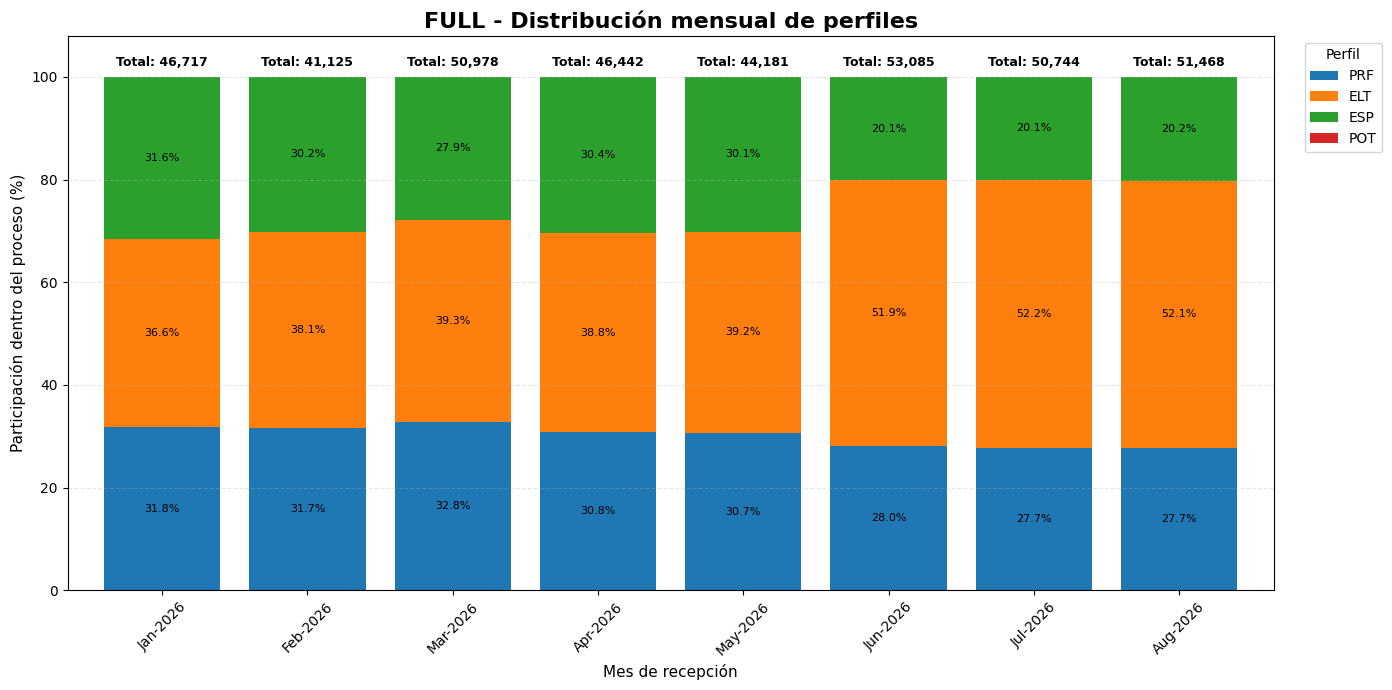

Tabla del proceso: FULL


SEGMICROPEQUENACOMERCIAL,PRF,ELT,ESP,POT,Total Proceso
mes,,,,,
2026-01-01,31.84%,36.57%,31.58%,0.00%,46717
2026-02-01,31.70%,38.14%,30.15%,0.00%,41125
2026-03-01,32.84%,39.31%,27.85%,0.00%,50978
2026-04-01,30.81%,38.81%,30.38%,0.00%,46442
2026-05-01,30.67%,39.20%,30.13%,0.00%,44181
2026-06-01,28.01%,51.87%,20.12%,0.00%,53085
2026-07-01,27.72%,52.21%,20.07%,0.00%,50744
2026-08-01,27.71%,52.11%,20.18%,0.00%,51468


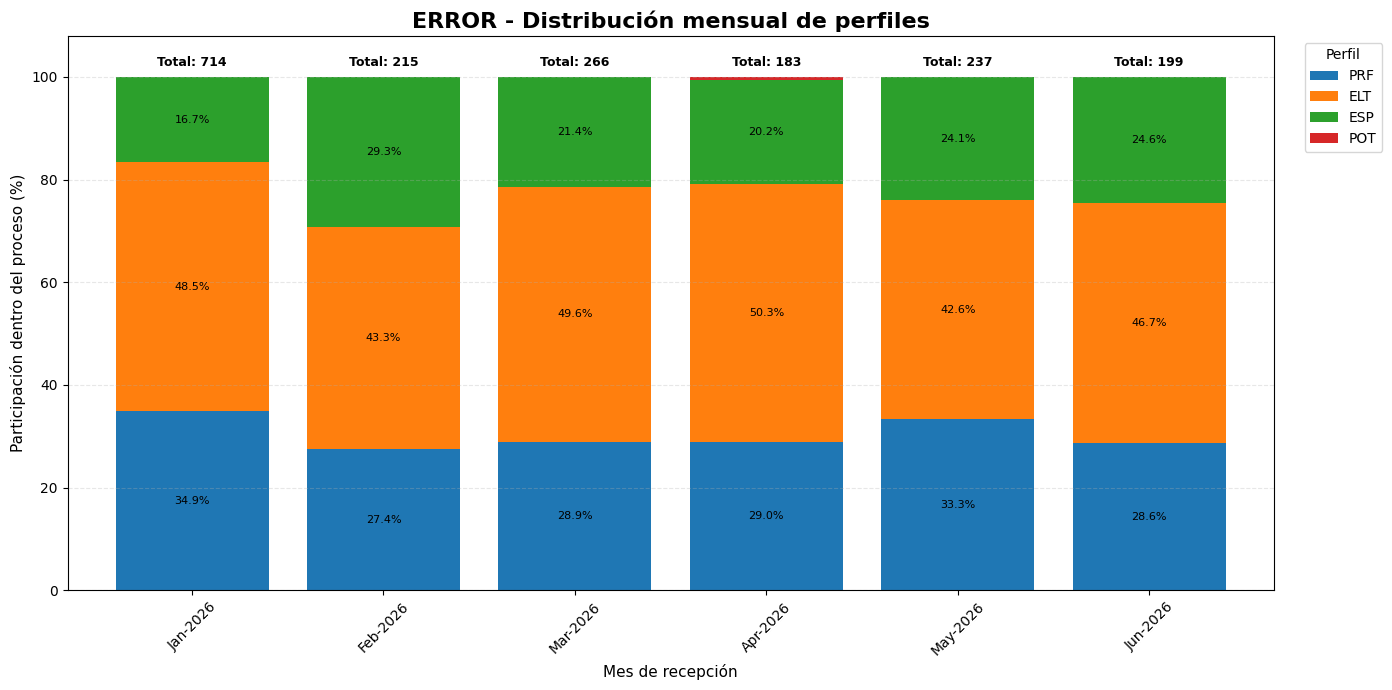

Tabla del proceso: ERROR


SEGMICROPEQUENACOMERCIAL,PRF,ELT,ESP,POT,Total Proceso
mes,,,,,
2026-01-01,34.87%,48.46%,16.67%,0.00%,714
2026-02-01,27.44%,43.26%,29.30%,0.00%,215
2026-03-01,28.95%,49.62%,21.43%,0.00%,266
2026-04-01,28.96%,50.27%,20.22%,0.55%,183
2026-05-01,33.33%,42.62%,24.05%,0.00%,237
2026-06-01,28.64%,46.73%,24.62%,0.00%,199


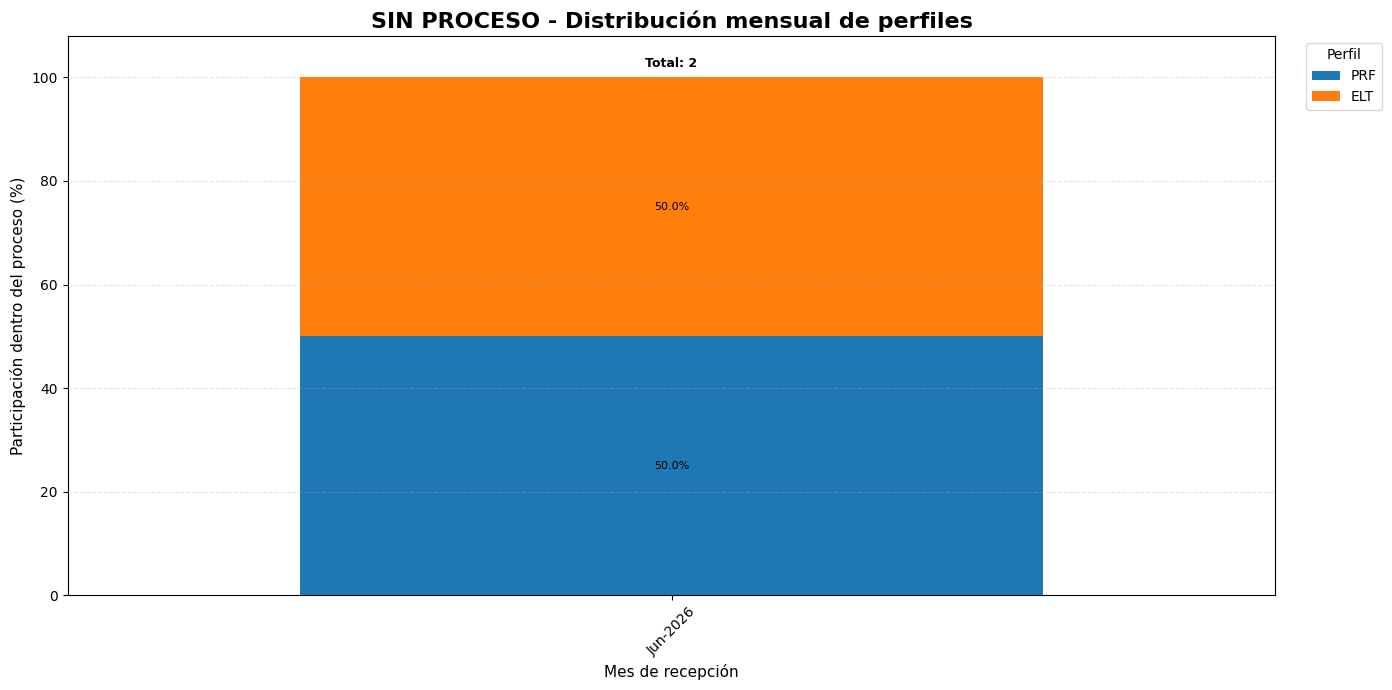

Tabla del proceso: SIN PROCESO


SEGMICROPEQUENACOMERCIAL,PRF,ELT,Total Proceso
mes,,,
2026-06-01,50.00%,50.00%,2


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PREPARAR LOS DATOS
# ============================================================
df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["Proceso"] = (
    df_grafico["Proceso"]
    .fillna("SIN PROCESO")
    .astype(str)
    .str.upper()
    .str.strip()
)

df_grafico["SEGMICROPEQUENACOMERCIAL"] = (
    df_grafico["SEGMICROPEQUENACOMERCIAL"]
    .fillna("SIN PERFIL")
    .astype(str)
    .str.upper()
    .str.strip()
)

# Eliminar filas sin mes
df_grafico = df_grafico.dropna(subset=["mes"])

# ============================================================
# ORDEN DE PROCESOS Y PERFILES
# ============================================================
orden_procesos = [
    "FASTTRACK",
    "HUMANO SEGURO",
    "FULL",
    "ERROR",
    "SIN PROCESO"
]

orden_perfiles = [
    "PRF",
    "ELT",
    "ESP",
    "POT",
    "SIN PERFIL"
]

# Considerar solo procesos existentes
procesos_existentes = [
    proceso
    for proceso in orden_procesos
    if proceso in df_grafico["Proceso"].unique()
]

# Agregar procesos no contemplados en el orden
otros_procesos = [
    proceso
    for proceso in df_grafico["Proceso"].unique()
    if proceso not in procesos_existentes
]

procesos_grafico = procesos_existentes + sorted(otros_procesos)

# ============================================================
# CREAR UN GRÁFICO POR PROCESO
# ============================================================
for proceso in procesos_grafico:

    # Filtrar proceso
    df_proceso = df_grafico[
        df_grafico["Proceso"] == proceso
    ].copy()

    if df_proceso.empty:
        continue

    # Cantidades por mes y perfil
    df_perfil = (
        df_proceso
        .groupby(
            ["mes", "SEGMICROPEQUENACOMERCIAL"]
        )["cantidad"]
        .sum()
        .unstack(fill_value=0)
        .sort_index()
    )

    # Perfiles existentes en el proceso
    perfiles_existentes = [
        perfil
        for perfil in orden_perfiles
        if perfil in df_perfil.columns
    ]

    # Incluir perfiles adicionales
    otros_perfiles = [
        perfil
        for perfil in df_perfil.columns
        if perfil not in perfiles_existentes
    ]

    columnas_perfil = perfiles_existentes + sorted(otros_perfiles)

    df_perfil = df_perfil[columnas_perfil]

    # Total mensual del proceso
    total_mes = df_perfil.sum(axis=1)

    # Evitar divisiones entre cero
    total_mes_seguro = total_mes.replace(0, pd.NA)

    # Participación porcentual del perfil dentro del proceso
    df_perfil_pct = (
        df_perfil
        .div(total_mes_seguro, axis=0)
        .mul(100)
        .fillna(0)
    )

    # ========================================================
    # GRÁFICO APILADO AL 100 %
    # ========================================================
    ax = df_perfil_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 7),
        width=0.80
    )

    # Porcentajes dentro de las barras
    for contenedor in ax.containers:

        etiquetas = []

        for barra in contenedor:
            valor = barra.get_height()

            etiquetas.append(
                f"{valor:.1f}%"
                if valor >= 3
                else ""
            )

        ax.bar_label(
            contenedor,
            labels=etiquetas,
            label_type="center",
            fontsize=8
        )

    # Total de registros encima de cada barra
    for posicion, total in enumerate(total_mes):
        ax.text(
            posicion,
            101.5,
            f"Total: {total:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    # ========================================================
    # FORMATO
    # ========================================================
    plt.title(
        f"{proceso} - Distribución mensual de perfiles",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Mes de recepción", fontsize=11)
    plt.ylabel("Participación dentro del proceso (%)", fontsize=11)

    plt.xticks(
        range(len(df_perfil_pct.index)),
        [
            fecha.strftime("%b-%Y")
            for fecha in df_perfil_pct.index
        ],
        rotation=45
    )

    plt.ylim(0, 108)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.legend(
        title="Perfil",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    # ========================================================
    # TABLA DEL PROCESO
    # ========================================================
    tabla_proceso = df_perfil_pct.copy()

    for columna in columnas_perfil:
        tabla_proceso[columna] = tabla_proceso[columna].map(
            lambda valor: f"{valor:.2f}%"
        )

    tabla_proceso["Total Proceso"] = total_mes.astype(int)

    print(f"Tabla del proceso: {proceso}")
    display(tabla_proceso)

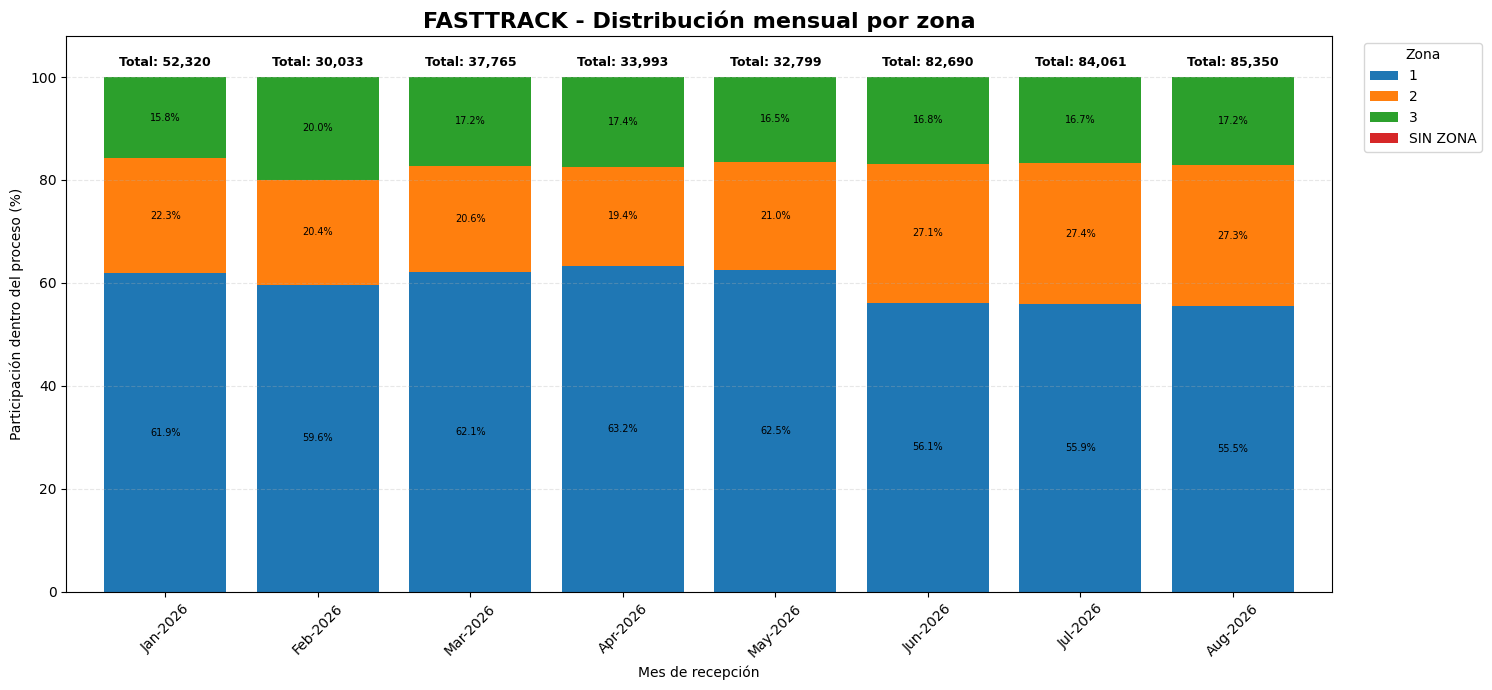

Tabla por zona del proceso: FASTTRACK


Zona,1,2,3,SIN ZONA,Total Proceso
mes,,,,,
2026-01-01,61.88%,22.33%,15.79%,0.00%,52320
2026-02-01,59.60%,20.41%,19.99%,0.00%,30033
2026-03-01,62.15%,20.61%,17.24%,0.00%,37765
2026-04-01,63.23%,19.38%,17.39%,0.00%,33993
2026-05-01,62.49%,21.02%,16.49%,0.00%,32799
2026-06-01,56.12%,27.05%,16.83%,0.00%,82690
2026-07-01,55.89%,27.38%,16.74%,0.00%,84061
2026-08-01,55.52%,27.31%,17.17%,0.00%,85350


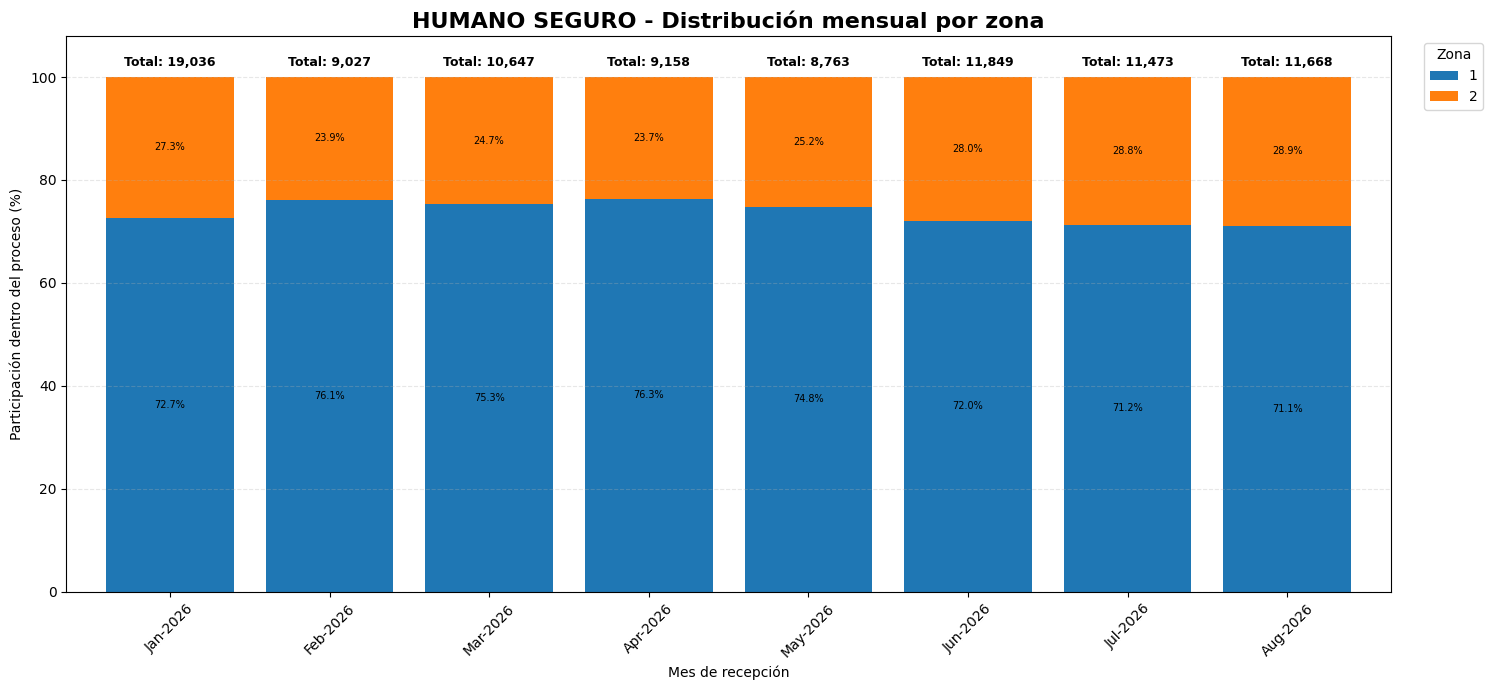

Tabla por zona del proceso: HUMANO SEGURO


Zona,1,2,Total Proceso
mes,,,
2026-01-01,72.70%,27.30%,19036
2026-02-01,76.12%,23.88%,9027
2026-03-01,75.32%,24.68%,10647
2026-04-01,76.35%,23.65%,9158
2026-05-01,74.77%,25.23%,8763
2026-06-01,72.01%,27.99%,11849
2026-07-01,71.23%,28.77%,11473
2026-08-01,71.08%,28.92%,11668


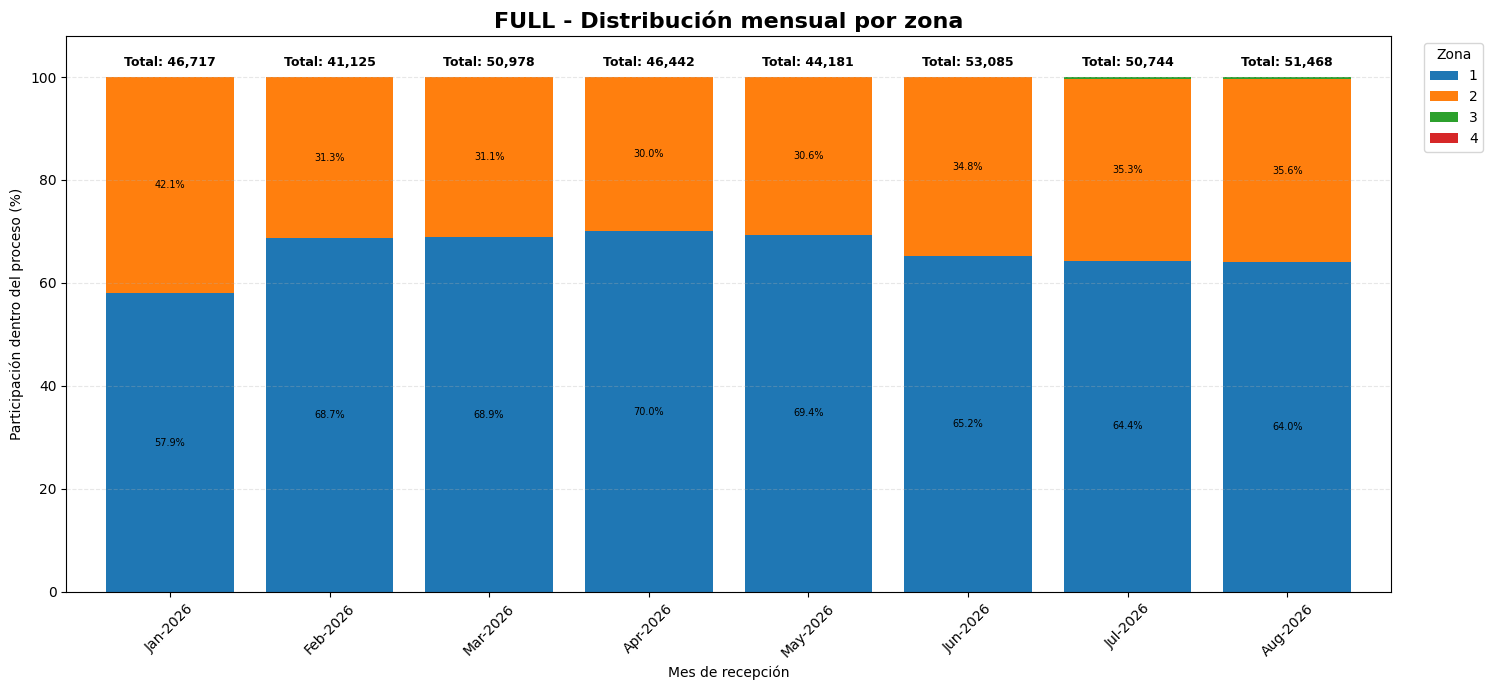

Tabla por zona del proceso: FULL


Zona,1,2,3,4,Total Proceso
mes,,,,,
2026-01-01,57.95%,42.05%,0.00%,0.00%,46717
2026-02-01,68.65%,31.35%,0.00%,0.00%,41125
2026-03-01,68.86%,31.14%,0.00%,0.00%,50978
2026-04-01,70.04%,29.96%,0.00%,0.00%,46442
2026-05-01,69.36%,30.64%,0.00%,0.00%,44181
2026-06-01,65.22%,34.78%,0.00%,0.00%,53085
2026-07-01,64.36%,35.26%,0.37%,0.02%,50744
2026-08-01,64.04%,35.56%,0.38%,0.02%,51468


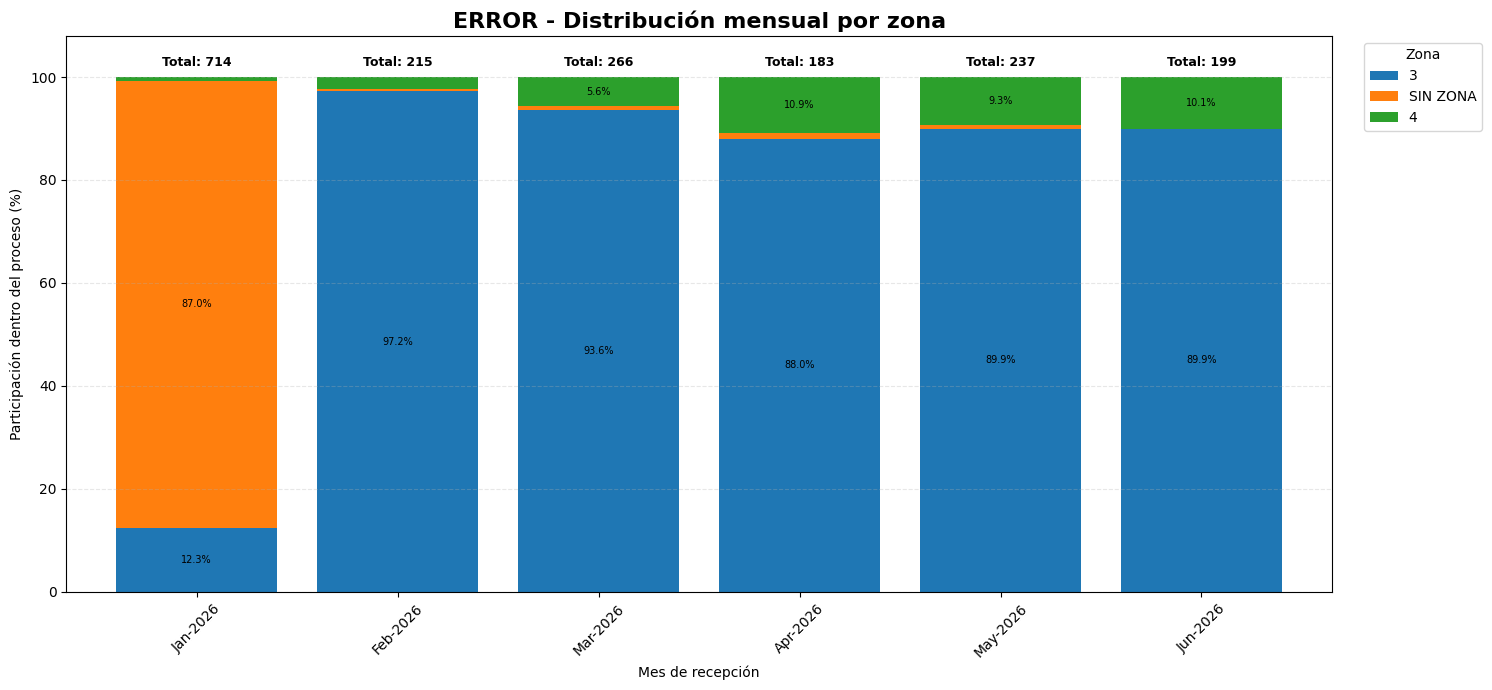

Tabla por zona del proceso: ERROR


Zona,3,SIN ZONA,4,Total Proceso
mes,,,,
2026-01-01,12.32%,86.97%,0.70%,714
2026-02-01,97.21%,0.47%,2.33%,215
2026-03-01,93.61%,0.75%,5.64%,266
2026-04-01,87.98%,1.09%,10.93%,183
2026-05-01,89.87%,0.84%,9.28%,237
2026-06-01,89.95%,0.00%,10.05%,199


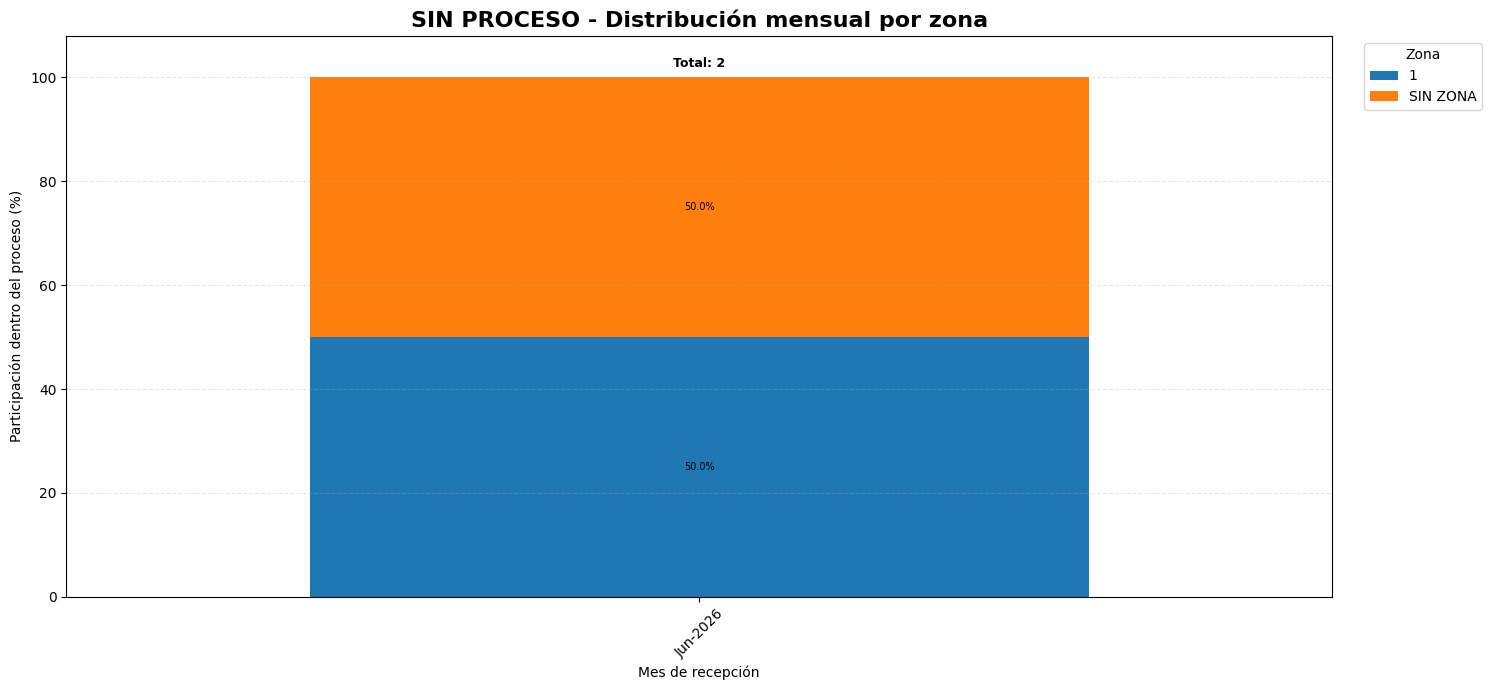

Tabla por zona del proceso: SIN PROCESO


Zona,1,SIN ZONA,Total Proceso
mes,,,
2026-06-01,50.00%,50.00%,2


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PREPARAR LOS DATOS
# ============================================================
df_grafico = df_filtrado.copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["Proceso"] = (
    df_grafico["Proceso"]
    .fillna("SIN PROCESO")
    .astype(str)
    .str.upper()
    .str.strip()
)

df_grafico["Zona"] = (
    df_grafico["Zona"]
    .fillna("SIN ZONA")
    .astype(str)
    .str.upper()
    .str.strip()
)

df_grafico = df_grafico.dropna(subset=["mes"])

# ============================================================
# ORDEN DE PROCESOS
# ============================================================
orden_procesos = [
    "FASTTRACK",
    "HUMANO SEGURO",
    "FULL",
    "ERROR",
    "SIN PROCESO"
]

procesos_existentes = [
    proceso
    for proceso in orden_procesos
    if proceso in df_grafico["Proceso"].unique()
]

otros_procesos = sorted([
    proceso
    for proceso in df_grafico["Proceso"].unique()
    if proceso not in procesos_existentes
])

procesos_grafico = procesos_existentes + otros_procesos

# ============================================================
# CREAR UN GRÁFICO POR PROCESO
# ============================================================
for proceso in procesos_grafico:

    df_proceso = df_grafico[
        df_grafico["Proceso"] == proceso
    ].copy()

    if df_proceso.empty:
        continue

    # Cantidad por mes y zona
    df_zona = (
        df_proceso
        .groupby(["mes", "Zona"])["cantidad"]
        .sum()
        .unstack(fill_value=0)
        .sort_index()
    )

    # Ordenar zonas según su volumen total
    orden_zonas = (
        df_zona
        .sum(axis=0)
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    df_zona = df_zona[orden_zonas]

    # Total mensual dentro del proceso
    total_mes = df_zona.sum(axis=1)

    # Porcentaje por zona dentro del proceso y mes
    df_zona_pct = (
        df_zona
        .div(total_mes.replace(0, pd.NA), axis=0)
        .mul(100)
        .fillna(0)
    )

    # ========================================================
    # GRÁFICO APILADO AL 100 %
    # ========================================================
    ax = df_zona_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(15, 7),
        width=0.80
    )

    # Etiquetas dentro de las barras
    for contenedor in ax.containers:

        etiquetas = []

        for barra in contenedor:
            valor = barra.get_height()

            etiquetas.append(
                f"{valor:.1f}%"
                if valor >= 5
                else ""
            )

        ax.bar_label(
            contenedor,
            labels=etiquetas,
            label_type="center",
            fontsize=7
        )

    # Total mensual encima
    for posicion, total in enumerate(total_mes):
        ax.text(
            posicion,
            101.5,
            f"Total: {total:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    # ========================================================
    # FORMATO
    # ========================================================
    plt.title(
        f"{proceso} - Distribución mensual por zona",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Mes de recepción")
    plt.ylabel("Participación dentro del proceso (%)")

    plt.xticks(
        range(len(df_zona_pct.index)),
        [
            fecha.strftime("%b-%Y")
            for fecha in df_zona_pct.index
        ],
        rotation=45
    )

    plt.ylim(0, 108)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.legend(
        title="Zona",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

    # ========================================================
    # TABLA
    # ========================================================
    tabla_zona = df_zona_pct.copy()

    for columna in tabla_zona.columns:
        tabla_zona[columna] = tabla_zona[columna].map(
            lambda valor: f"{valor:.2f}%"
        )

    tabla_zona["Total Proceso"] = total_mes.astype(int)

    print(f"Tabla por zona del proceso: {proceso}")
    display(tabla_zona)

In [34]:
import pandas as pd
import numpy as np

# ============================================================
# PREPARAR DATOS
# ============================================================
df_tabla = df_filtrado.copy()

df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

df_tabla["cantidad"] = pd.to_numeric(
    df_tabla["cantidad"],
    errors="coerce"
).fillna(0)

df_tabla["Proceso"] = (
    df_tabla["Proceso"]
    .fillna("SIN PROCESO")
    .astype(str)
    .str.upper()
    .str.strip()
)

df_tabla["SEGMICROPEQUENACOMERCIAL"] = (
    df_tabla["SEGMICROPEQUENACOMERCIAL"]
    .fillna("SIN PERFIL")
    .astype(str)
    .str.upper()
    .str.strip()
)

df_tabla["Zona"] = (
    df_tabla["Zona"]
    .fillna("SIN ZONA")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# CANTIDAD POR MES-PROCESO-PERFIL-ZONA
# ============================================================
df_resumen = (
    df_tabla
    .groupby(
        [
            "mes",
            "Proceso",
            "SEGMICROPEQUENACOMERCIAL",
            "Zona"
        ],
        as_index=False
    )["cantidad"]
    .sum()
)

# ============================================================
# TOTAL POR MES Y PROCESO
# ============================================================
df_total = (
    df_resumen
    .groupby(
        ["mes","Proceso"],
        as_index=False
    )["cantidad"]
    .sum()
    .rename(
        columns={
            "cantidad":"Total_Proceso"
        }
    )
)

df_resumen = df_resumen.merge(
    df_total,
    on=["mes","Proceso"],
    how="left"
)

# ============================================================
# PARTICIPACIÓN DENTRO DEL PROCESO
# ============================================================
df_resumen["Participacion"] = (
    df_resumen["cantidad"]
    / df_resumen["Total_Proceso"]
    *100
)

# ============================================================
# TABLA PIVOT
# ============================================================
tabla = (
    df_resumen
    .pivot_table(
        index=[
            "Proceso",
            "SEGMICROPEQUENACOMERCIAL",
            "Zona"
        ],
        columns="mes",
        values="Participacion",
        aggfunc="sum",
        fill_value=0
    )
)

# ============================================================
# ORDENAR COLUMNAS (MESES)
# ============================================================
tabla = tabla.sort_index(axis=1)

tabla.columns = [
    fecha.strftime("%b-%Y")
    for fecha in tabla.columns
]

# ============================================================
# AGREGAR PROMEDIO DEL PERIODO
# ============================================================
tabla["Promedio"] = tabla.mean(axis=1)

# ============================================================
# FORMATO
# ============================================================
tabla = tabla.reset_index()

columnas_meses = [
    c
    for c in tabla.columns
    if c not in [
        "Proceso",
        "SEGMICROPEQUENACOMERCIAL",
        "Zona"
    ]
]

for c in columnas_meses:
    tabla[c] = tabla[c].map(lambda x: f"{x:.2f}%")

display(tabla)

,Proceso,SEGMICROPEQUENACOMERCIAL,Zona,Jan-2026,Feb-2026,Mar-2026,Apr-2026,May-2026,Jun-2026,Jul-2026,Aug-2026,Promedio
0,ERROR,ELT,3,5.04%,42.33%,46.62%,45.36%,39.66%,43.72%,0.00%,0.00%,27.84%
1,ERROR,ELT,4,0.56%,0.93%,3.01%,4.92%,2.95%,3.02%,0.00%,0.00%,1.92%
2,ERROR,ELT,SIN ZONA,42.86%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,5.36%
3,ERROR,ESP,3,4.48%,28.84%,21.43%,18.58%,22.36%,22.61%,0.00%,0.00%,14.79%
4,ERROR,ESP,4,0.00%,0.47%,0.00%,1.09%,1.27%,2.01%,0.00%,0.00%,0.60%
5,ERROR,ESP,SIN ZONA,12.18%,0.00%,0.00%,0.55%,0.42%,0.00%,0.00%,0.00%,1.64%
6,ERROR,POT,SIN ZONA,0.00%,0.00%,0.00%,0.55%,0.00%,0.00%,0.00%,0.00%,0.07%
7,ERROR,PRF,3,2.80%,26.05%,25.56%,24.04%,27.85%,23.62%,0.00%,0.00%,16.24%
8,ERROR,PRF,4,0.14%,0.93%,2.63%,4.92%,5.06%,5.03%,0.00%,0.00%,2.34%
9,ERROR,PRF,SIN ZONA,31.93%,0.47%,0.75%,0.00%,0.42%,0.00%,0.00%,0.00%,4.20%


In [35]:
# ============================================================
# TABLA PIVOT
# ============================================================
tabla = (
    df_resumen
    .pivot_table(
        index=[
            "Proceso",
            "SEGMICROPEQUENACOMERCIAL",
            "Zona"
        ],
        columns="mes",
        values="Participacion",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index(axis=1)
)

# Guardamos las fechas originales antes de cambiar sus nombres
fechas_meses = list(tabla.columns)

# ============================================================
# IDENTIFICAR MESES ACTIVOS POR PROCESO
# ============================================================
# Cantidad total registrada por proceso y mes
totales_proceso_mes = (
    df_resumen
    .groupby(["Proceso", "mes"])["cantidad"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=fechas_meses, fill_value=0)
)

# ============================================================
# PROMEDIO SOLO SOBRE MESES ACTIVOS
# ============================================================
def promedio_meses_activos(fila):
    proceso = fila.name[0]

    meses_activos = (
        totales_proceso_mes.loc[proceso] > 0
    )

    valores_activos = fila.loc[meses_activos]

    if len(valores_activos) == 0:
        return np.nan

    return valores_activos.mean()


tabla["Promedio_activo"] = tabla.apply(
    promedio_meses_activos,
    axis=1
)

# ============================================================
# MÉTRICAS DE ESTABILIDAD
# ============================================================
columnas_mes_fecha = fechas_meses

tabla["Minimo"] = tabla[columnas_mes_fecha].min(axis=1)
tabla["Maximo"] = tabla[columnas_mes_fecha].max(axis=1)
tabla["Rango_pp"] = tabla["Maximo"] - tabla["Minimo"]
tabla["Desviacion_pp"] = tabla[columnas_mes_fecha].std(axis=1)

# ============================================================
# ÚLTIMOS DOS MESES DISPONIBLES POR PROCESO
# ============================================================
def obtener_ultimos_meses(fila):
    proceso = fila.name[0]

    meses_activos = [
        mes
        for mes in columnas_mes_fecha
        if totales_proceso_mes.loc[proceso, mes] > 0
    ]

    if len(meses_activos) == 0:
        return pd.Series({
            "Mes_anterior": np.nan,
            "Ultimo_mes": np.nan,
            "Variacion_pp": np.nan
        })

    ultimo_mes = meses_activos[-1]
    valor_ultimo = fila[ultimo_mes]

    if len(meses_activos) >= 2:
        mes_anterior = meses_activos[-2]
        valor_anterior = fila[mes_anterior]
        variacion = valor_ultimo - valor_anterior
    else:
        valor_anterior = np.nan
        variacion = np.nan

    return pd.Series({
        "Mes_anterior": valor_anterior,
        "Ultimo_mes": valor_ultimo,
        "Variacion_pp": variacion
    })


metricas_ultimos_meses = tabla.apply(
    obtener_ultimos_meses,
    axis=1
)

tabla = pd.concat(
    [
        tabla,
        metricas_ultimos_meses
    ],
    axis=1
)

# ============================================================
# CLASIFICACIÓN DE ESTABILIDAD
# ============================================================
def clasificar_estabilidad(desviacion):
    if pd.isna(desviacion):
        return "SIN INFORMACIÓN"
    elif desviacion <= 2:
        return "ESTABLE"
    elif desviacion <= 5:
        return "VARIACIÓN MODERADA"
    else:
        return "ALTA VARIACIÓN"


tabla["Estabilidad"] = tabla["Desviacion_pp"].apply(
    clasificar_estabilidad
)

# ============================================================
# CAMBIAR NOMBRES DE LOS MESES
# ============================================================
renombre_meses = {
    fecha: fecha.strftime("%b-%Y")
    for fecha in fechas_meses
}

tabla = tabla.rename(columns=renombre_meses)

# ============================================================
# RESETEAR ÍNDICE
# ============================================================
tabla = tabla.reset_index()

# ============================================================
# ORDENAR COLUMNAS
# ============================================================
columnas_meses = [
    fecha.strftime("%b-%Y")
    for fecha in fechas_meses
]

columnas_finales = [
    "Proceso",
    "SEGMICROPEQUENACOMERCIAL",
    "Zona"
] + columnas_meses + [
    "Promedio_activo",
    "Mes_anterior",
    "Ultimo_mes",
    "Variacion_pp",
    "Rango_pp",
    "Desviacion_pp",
    "Estabilidad"
]

tabla = tabla[columnas_finales]

# ============================================================
# FORMATO PORCENTUAL
# ============================================================
columnas_porcentaje = (
    columnas_meses
    + [
        "Promedio_activo",
        "Mes_anterior",
        "Ultimo_mes",
        "Variacion_pp",
        "Rango_pp",
        "Desviacion_pp"
    ]
)

for columna in columnas_porcentaje:
    tabla[columna] = tabla[columna].apply(
        lambda x: f"{x:.2f}%"
        if pd.notna(x)
        else "-"
    )

display(tabla)

,Proceso,SEGMICROPEQUENACOMERCIAL,Zona,Jan-2026,Feb-2026,Mar-2026,Apr-2026,May-2026,Jun-2026,Jul-2026,Aug-2026,Promedio_activo,Mes_anterior,Ultimo_mes,Variacion_pp,Rango_pp,Desviacion_pp,Estabilidad
0,ERROR,ELT,3,5.04%,42.33%,46.62%,45.36%,39.66%,43.72%,0.00%,0.00%,37.12%,39.66%,43.72%,4.06%,46.62%,21.81%,ALTA VARIACIÓN
1,ERROR,ELT,4,0.56%,0.93%,3.01%,4.92%,2.95%,3.02%,0.00%,0.00%,2.56%,2.95%,3.02%,0.06%,4.92%,1.80%,ESTABLE
2,ERROR,ELT,SIN ZONA,42.86%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,7.14%,0.00%,0.00%,0.00%,42.86%,15.15%,ALTA VARIACIÓN
3,ERROR,ESP,3,4.48%,28.84%,21.43%,18.58%,22.36%,22.61%,0.00%,0.00%,19.72%,22.36%,22.61%,0.25%,28.84%,11.45%,ALTA VARIACIÓN
4,ERROR,ESP,4,0.00%,0.47%,0.00%,1.09%,1.27%,2.01%,0.00%,0.00%,0.81%,1.27%,2.01%,0.74%,2.01%,0.77%,ESTABLE
5,ERROR,ESP,SIN ZONA,12.18%,0.00%,0.00%,0.55%,0.42%,0.00%,0.00%,0.00%,2.19%,0.42%,0.00%,-0.42%,12.18%,4.26%,VARIACIÓN MODERADA
6,ERROR,POT,SIN ZONA,0.00%,0.00%,0.00%,0.55%,0.00%,0.00%,0.00%,0.00%,0.09%,0.00%,0.00%,0.00%,0.55%,0.19%,ESTABLE
7,ERROR,PRF,3,2.80%,26.05%,25.56%,24.04%,27.85%,23.62%,0.00%,0.00%,21.65%,27.85%,23.62%,-4.23%,27.85%,12.77%,ALTA VARIACIÓN
8,ERROR,PRF,4,0.14%,0.93%,2.63%,4.92%,5.06%,5.03%,0.00%,0.00%,3.12%,5.06%,5.03%,-0.04%,5.06%,2.36%,VARIACIÓN MODERADA
9,ERROR,PRF,SIN ZONA,31.93%,0.47%,0.75%,0.00%,0.42%,0.00%,0.00%,0.00%,5.60%,0.42%,0.00%,-0.42%,31.93%,11.21%,ALTA VARIACIÓN


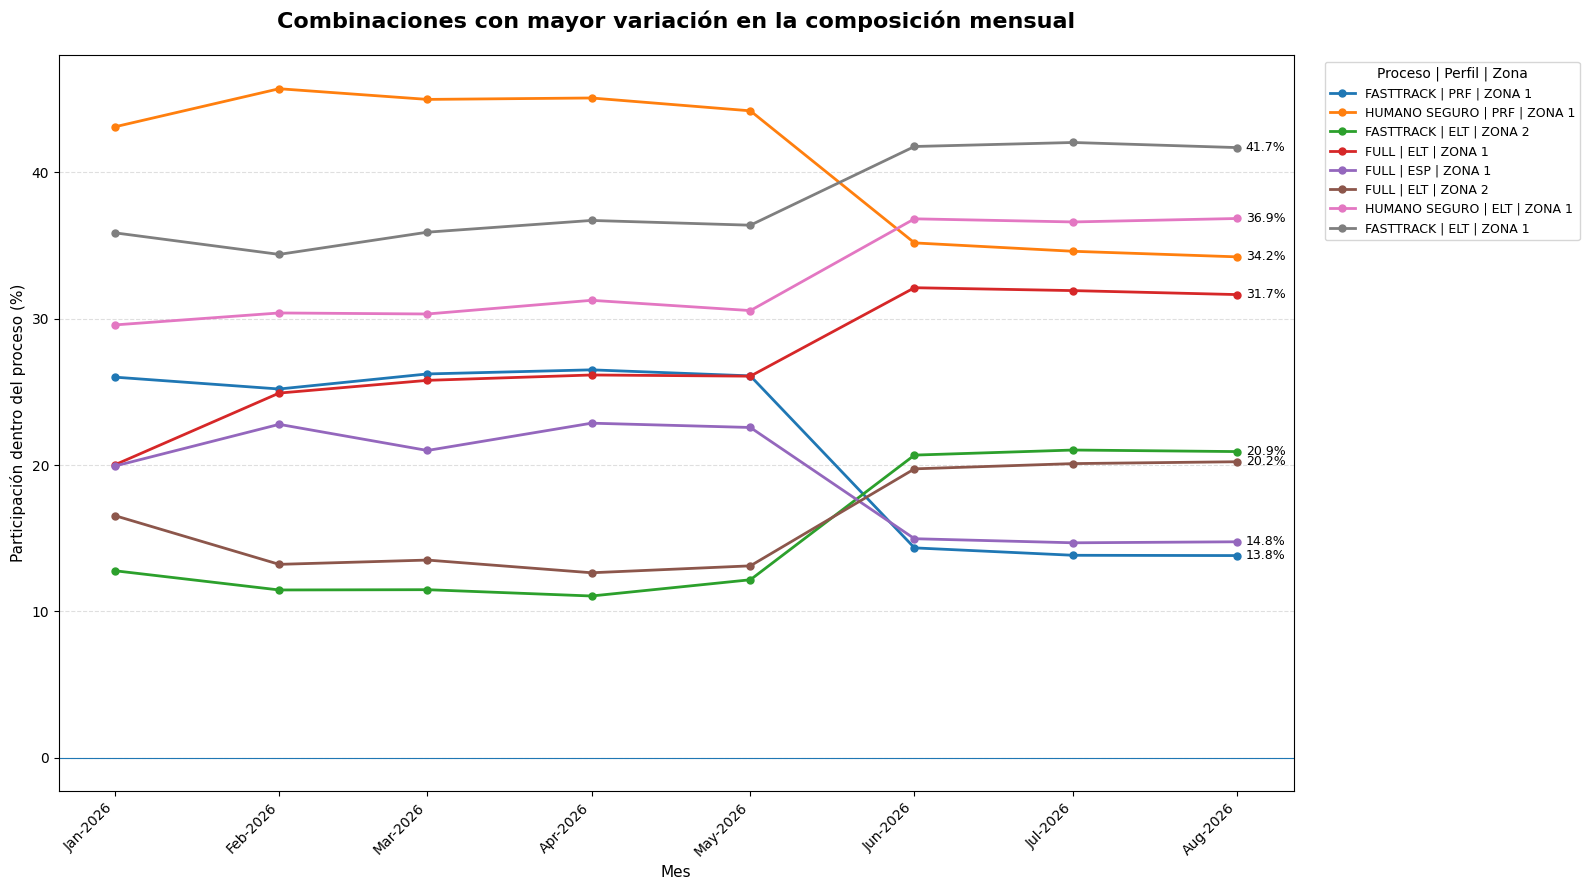

,Proceso,SEGMICROPEQUENACOMERCIAL,Zona,Promedio,Minimo,Maximo,Rango_pp,Desviacion_pp,Cambio_inicio_fin_pp,Variacion_ultimo_mes_pp,Estabilidad,Tendencia
0,FASTTRACK,PRF,1,21.51%,13.82%,26.51%,12.69%,5.83%,-12.19 pp,-0.02 pp,ALTA VARIACIÓN,DISMINUYÓ
1,HUMANO SEGURO,PRF,1,40.89%,34.23%,45.72%,11.49%,4.87%,-8.89 pp,-0.38 pp,VARIACIÓN MODERADA,DISMINUYÓ
2,FASTTRACK,ELT,2,15.20%,11.06%,21.03%,9.97%,4.43%,+8.14 pp,-0.11 pp,VARIACIÓN MODERADA,AUMENTÓ
3,FULL,ELT,1,27.34%,20.03%,32.12%,12.10%,3.99%,+11.63 pp,-0.27 pp,VARIACIÓN MODERADA,AUMENTÓ
4,FULL,ESP,1,19.20%,14.69%,22.87%,8.17%,3.52%,-5.18 pp,+0.07 pp,VARIACIÓN MODERADA,DISMINUYÓ
5,FULL,ELT,2,16.14%,12.65%,20.23%,7.59%,3.21%,+3.69 pp,+0.13 pp,VARIACIÓN MODERADA,AUMENTÓ
6,HUMANO SEGURO,ELT,1,32.80%,29.58%,36.85%,7.27%,3.10%,+7.27 pp,+0.24 pp,VARIACIÓN MODERADA,AUMENTÓ
7,FASTTRACK,ELT,1,38.10%,34.40%,42.05%,7.65%,2.96%,+5.82 pp,-0.35 pp,VARIACIÓN MODERADA,AUMENTÓ


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

# Cantidad máxima de líneas que aparecerán en el gráfico
TOP_N = 8

# Ignorar procesos que no deseas analizar
PROCESOS_EXCLUIR = [
    "ERROR",
    "SIN PROCESO"
]

# Mínimo promedio de participación para aparecer en el gráfico.
# Evita mostrar combinaciones muy pequeñas con cambios poco relevantes.
PARTICIPACION_MINIMA = 1.0


# ============================================================
# 2. PREPARAR DATOS
# ============================================================

df_tabla = df_filtrado.copy()

df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

df_tabla["cantidad"] = pd.to_numeric(
    df_tabla["cantidad"],
    errors="coerce"
).fillna(0)

df_tabla["Proceso"] = (
    df_tabla["Proceso"]
    .fillna("SIN PROCESO")
    .astype(str)
    .str.upper()
    .str.strip()
)

df_tabla["SEGMICROPEQUENACOMERCIAL"] = (
    df_tabla["SEGMICROPEQUENACOMERCIAL"]
    .fillna("SIN PERFIL")
    .astype(str)
    .str.upper()
    .str.strip()
)

# Dejamos Zona como texto porque también puede existir SIN ZONA
df_tabla["Zona"] = (
    df_tabla["Zona"]
    .fillna("SIN ZONA")
    .astype(str)
    .str.upper()
    .str.strip()
)

# Eliminar registros sin fecha válida
df_tabla = df_tabla[
    df_tabla["mes"].notna()
].copy()


# ============================================================
# 3. CANTIDAD POR MES, PROCESO, PERFIL Y ZONA
# ============================================================

df_resumen = (
    df_tabla
    .groupby(
        [
            "mes",
            "Proceso",
            "SEGMICROPEQUENACOMERCIAL",
            "Zona"
        ],
        as_index=False
    )["cantidad"]
    .sum()
)


# ============================================================
# 4. TOTAL POR MES Y PROCESO
# ============================================================

df_total = (
    df_resumen
    .groupby(
        [
            "mes",
            "Proceso"
        ],
        as_index=False
    )["cantidad"]
    .sum()
    .rename(
        columns={
            "cantidad": "Total_Proceso"
        }
    )
)

df_resumen = df_resumen.merge(
    df_total,
    on=[
        "mes",
        "Proceso"
    ],
    how="left"
)


# ============================================================
# 5. PARTICIPACIÓN DENTRO DE CADA PROCESO
# ============================================================

df_resumen["Participacion"] = np.where(
    df_resumen["Total_Proceso"] > 0,
    (
        df_resumen["cantidad"]
        / df_resumen["Total_Proceso"]
        * 100
    ),
    np.nan
)


# ============================================================
# 6. CREAR IDENTIFICADOR PARA EL GRÁFICO
# ============================================================

df_resumen["Combinacion"] = (
    df_resumen["Proceso"]
    + " | "
    + df_resumen["SEGMICROPEQUENACOMERCIAL"]
    + " | ZONA "
    + df_resumen["Zona"]
)


# ============================================================
# 7. EXCLUIR PROCESOS NO DESEADOS
# ============================================================

df_grafico = df_resumen[
    ~df_resumen["Proceso"].isin(PROCESOS_EXCLUIR)
].copy()


# ============================================================
# 8. CREAR TABLA PIVOT NUMÉRICA
# ============================================================

tabla_numerica = (
    df_grafico
    .pivot_table(
        index=[
            "Proceso",
            "SEGMICROPEQUENACOMERCIAL",
            "Zona",
            "Combinacion"
        ],
        columns="mes",
        values="Participacion",
        aggfunc="sum"
    )
    .sort_index(axis=1)
)


# ============================================================
# 9. DETECTAR MESES ACTIVOS POR PROCESO
# ============================================================

totales_proceso_mes = (
    df_grafico
    .groupby(
        [
            "Proceso",
            "mes"
        ]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
    .reindex(
        columns=tabla_numerica.columns,
        fill_value=0
    )
)


# ============================================================
# 10. CALCULAR MÉTRICAS SOLO CON MESES ACTIVOS
# ============================================================

def calcular_metricas(fila):

    proceso = fila.name[0]

    if proceso not in totales_proceso_mes.index:
        return pd.Series({
            "Promedio": np.nan,
            "Minimo": np.nan,
            "Maximo": np.nan,
            "Rango_pp": np.nan,
            "Desviacion_pp": np.nan,
            "Mes_anterior": np.nan,
            "Ultimo_mes": np.nan,
            "Variacion_ultimo_mes_pp": np.nan,
            "Cambio_inicio_fin_pp": np.nan
        })

    meses_activos = (
        totales_proceso_mes.loc[proceso] > 0
    )

    meses_validos = [
        mes
        for mes in tabla_numerica.columns
        if meses_activos.get(mes, False)
    ]

    if len(meses_validos) == 0:
        return pd.Series({
            "Promedio": np.nan,
            "Minimo": np.nan,
            "Maximo": np.nan,
            "Rango_pp": np.nan,
            "Desviacion_pp": np.nan,
            "Mes_anterior": np.nan,
            "Ultimo_mes": np.nan,
            "Variacion_ultimo_mes_pp": np.nan,
            "Cambio_inicio_fin_pp": np.nan
        })

    valores = fila[meses_validos].fillna(0)

    promedio = valores.mean()
    minimo = valores.min()
    maximo = valores.max()
    rango = maximo - minimo
    desviacion = valores.std(ddof=0)

    primer_valor = valores.iloc[0]
    ultimo_valor = valores.iloc[-1]

    if len(valores) >= 2:
        valor_anterior = valores.iloc[-2]
        variacion_ultimo_mes = ultimo_valor - valor_anterior
    else:
        valor_anterior = np.nan
        variacion_ultimo_mes = np.nan

    cambio_inicio_fin = ultimo_valor - primer_valor

    return pd.Series({
        "Promedio": promedio,
        "Minimo": minimo,
        "Maximo": maximo,
        "Rango_pp": rango,
        "Desviacion_pp": desviacion,
        "Mes_anterior": valor_anterior,
        "Ultimo_mes": ultimo_valor,
        "Variacion_ultimo_mes_pp": variacion_ultimo_mes,
        "Cambio_inicio_fin_pp": cambio_inicio_fin
    })


metricas = tabla_numerica.apply(
    calcular_metricas,
    axis=1
)

tabla_analisis = pd.concat(
    [
        tabla_numerica,
        metricas
    ],
    axis=1
).reset_index()


# ============================================================
# 11. CLASIFICAR ESTABILIDAD
# ============================================================

def clasificar_estabilidad(desviacion):

    if pd.isna(desviacion):
        return "SIN INFORMACIÓN"

    if desviacion <= 2:
        return "ESTABLE"

    if desviacion <= 5:
        return "VARIACIÓN MODERADA"

    return "ALTA VARIACIÓN"


tabla_analisis["Estabilidad"] = (
    tabla_analisis["Desviacion_pp"]
    .apply(clasificar_estabilidad)
)


# ============================================================
# 12. CLASIFICAR TENDENCIA
# ============================================================

def clasificar_tendencia(cambio):

    if pd.isna(cambio):
        return "SIN INFORMACIÓN"

    if cambio >= 2:
        return "AUMENTÓ"

    if cambio <= -2:
        return "DISMINUYÓ"

    return "SE MANTIENE"


tabla_analisis["Tendencia"] = (
    tabla_analisis["Cambio_inicio_fin_pp"]
    .apply(clasificar_tendencia)
)


# ============================================================
# 13. FILTRAR PARTICIPACIONES RELEVANTES
# ============================================================

tabla_relevante = tabla_analisis[
    tabla_analisis["Promedio"] >= PARTICIPACION_MINIMA
].copy()


# ============================================================
# 14. SELECCIONAR LOS CASOS MÁS RESALTANTES
# ============================================================

# Se ordena por desviación mensual.
# Los primeros serán aquellos cuya composición cambió más.

top_variaciones = (
    tabla_relevante
    .sort_values(
        by=[
            "Desviacion_pp",
            "Rango_pp"
        ],
        ascending=False
    )
    .head(TOP_N)
    .copy()
)


# ============================================================
# 15. PREPARAR DATOS PARA EL GRÁFICO
# ============================================================

columnas_meses = list(tabla_numerica.columns)

df_lineas = (
    top_variaciones[
        [
            "Combinacion"
        ] + columnas_meses
    ]
    .set_index("Combinacion")
    .T
)

df_lineas.index = pd.to_datetime(
    df_lineas.index
)


# ============================================================
# 16. GRÁFICO DE LÍNEAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9)
)

for combinacion in df_lineas.columns:

    serie = df_lineas[combinacion]

    ax.plot(
        df_lineas.index,
        serie,
        marker="o",
        linewidth=2,
        markersize=5,
        label=combinacion
    )

    # Mostrar etiqueta en el último punto
    valores_validos = serie.dropna()

    if not valores_validos.empty:

        ultimo_mes = valores_validos.index[-1]
        ultimo_valor = valores_validos.iloc[-1]

        ax.annotate(
            f"{ultimo_valor:.1f}%",
            xy=(
                ultimo_mes,
                ultimo_valor
            ),
            xytext=(6, 0),
            textcoords="offset points",
            fontsize=9,
            va="center"
        )


# Línea horizontal de referencia
ax.axhline(
    y=0,
    linewidth=0.8
)

ax.set_title(
    "Combinaciones con mayor variación en la composición mensual",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Mes",
    fontsize=11
)

ax.set_ylabel(
    "Participación dentro del proceso (%)",
    fontsize=11
)

ax.set_xticks(df_lineas.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_lineas.index
    ],
    rotation=45,
    ha="right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Proceso | Perfil | Zona",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. TABLA CON LOS PUNTOS MÁS RESALTANTES
# ============================================================

columnas_resultado = [
    "Proceso",
    "SEGMICROPEQUENACOMERCIAL",
    "Zona",
    "Promedio",
    "Minimo",
    "Maximo",
    "Rango_pp",
    "Desviacion_pp",
    "Cambio_inicio_fin_pp",
    "Variacion_ultimo_mes_pp",
    "Estabilidad",
    "Tendencia"
]

tabla_puntos_resaltantes = (
    top_variaciones[
        columnas_resultado
    ]
    .sort_values(
        "Desviacion_pp",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 18. FORMATO PARA MOSTRAR
# ============================================================

columnas_porcentaje = [
    "Promedio",
    "Minimo",
    "Maximo",
    "Rango_pp",
    "Desviacion_pp",
    "Cambio_inicio_fin_pp",
    "Variacion_ultimo_mes_pp"
]

tabla_mostrar = tabla_puntos_resaltantes.copy()

for columna in columnas_porcentaje:

    tabla_mostrar[columna] = (
        tabla_mostrar[columna]
        .apply(
            lambda x: (
                f"{x:+.2f} pp"
                if columna in [
                    "Cambio_inicio_fin_pp",
                    "Variacion_ultimo_mes_pp"
                ] and pd.notna(x)
                else (
                    f"{x:.2f}%"
                    if pd.notna(x)
                    else "-"
                )
            )
        )
    )

display(tabla_mostrar)

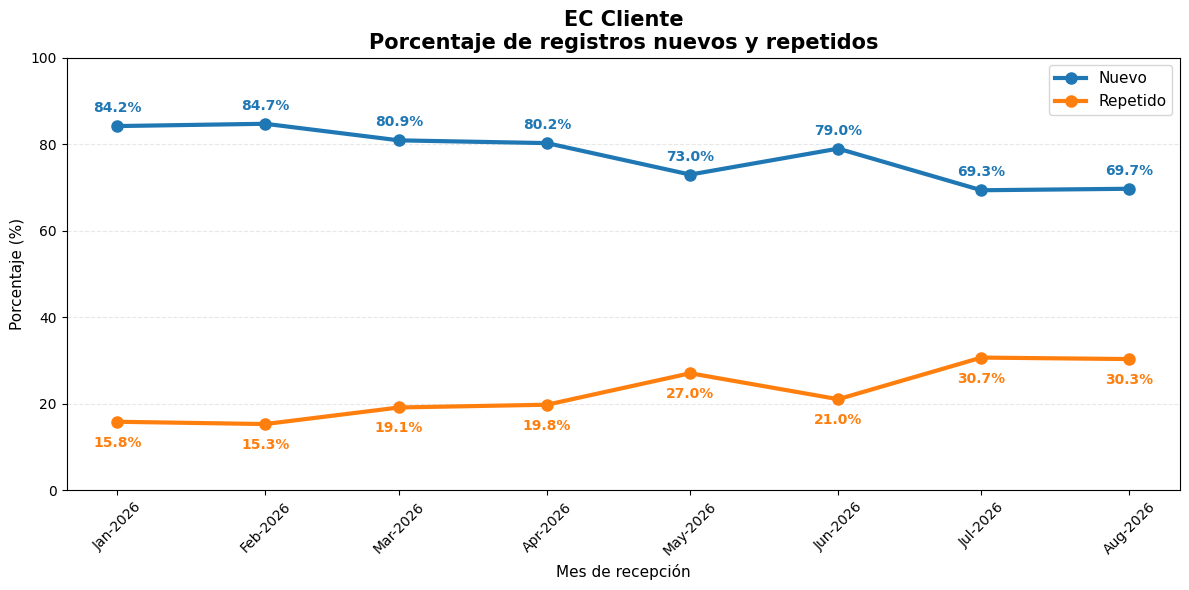

Tipo,Nuevo,Repetido,Total,Porcentaje_nuevo,Porcentaje_repetido
mes,,,,,
2026-01-01,31804,5984,37788,84.16,15.84
2026-02-01,27519,4974,32493,84.69,15.31
2026-03-01,29518,6986,36504,80.86,19.14
2026-04-01,33093,8157,41250,80.23,19.77
2026-05-01,24862,9217,34079,72.95,27.05
2026-06-01,40859,10893,51752,78.95,21.05
2026-07-01,30307,13405,43712,69.33,30.67
2026-08-01,16551,7203,23754,69.68,30.32


In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PRODUCTO A ANALIZAR
# ============================================================
producto_seleccionado = "EC Cliente"   # Cambiar por AEC, AER, CD, etc.

# ============================================================
# FILTRAR PRODUCTO
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Asegurar tipos
df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])
df_grafico["diferencia"] = pd.to_numeric(df_grafico["diferencia"], errors="coerce")
df_grafico["cantidad"] = pd.to_numeric(df_grafico["cantidad"], errors="coerce").fillna(0)

# ============================================================
# NUEVO O REPETIDO
# ============================================================
df_grafico["Tipo"] = df_grafico["diferencia"].apply(
    lambda x: "Nuevo" if x == 0 else "Repetido"
)

# ============================================================
# RESUMEN MENSUAL
# ============================================================
df_resumen_grafico = (
    df_grafico
    .groupby(["mes", "Tipo"])["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# En caso de que falte alguna columna
for col in ["Nuevo", "Repetido"]:
    if col not in df_resumen_grafico.columns:
        df_resumen_grafico[col] = 0

df_resumen_grafico["Total"] = (
    df_resumen_grafico["Nuevo"] +
    df_resumen_grafico["Repetido"]
)

df_resumen_grafico["Porcentaje_nuevo"] = (
    df_resumen_grafico["Nuevo"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico["Porcentaje_repetido"] = (
    df_resumen_grafico["Repetido"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico = df_resumen_grafico.sort_index()

# ============================================================
# GRAFICO
# ============================================================
plt.figure(figsize=(12,6))

# Línea azul
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#1f77b4",
    label="Nuevo"
)

# Línea naranja
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#ff7f0e",
    label="Repetido"
)

# ============================================================
# ETIQUETAS NUEVO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,10),
        textcoords="offset points",
        ha="center",
        color="#1f77b4",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# ETIQUETAS REPETIDO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,-18),
        textcoords="offset points",
        ha="center",
        color="#ff7f0e",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"{producto_seleccionado}\nPorcentaje de registros nuevos y repetidos",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Porcentaje (%)", fontsize=11)

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(fontsize=11)

plt.xticks(
    df_resumen_grafico.index,
    [d.strftime("%b-%Y") for d in df_resumen_grafico.index],
    rotation=45
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_resumen_grafico[
        [
            "Nuevo",
            "Repetido",
            "Total",
            "Porcentaje_nuevo",
            "Porcentaje_repetido"
        ]
    ].round(2)
)

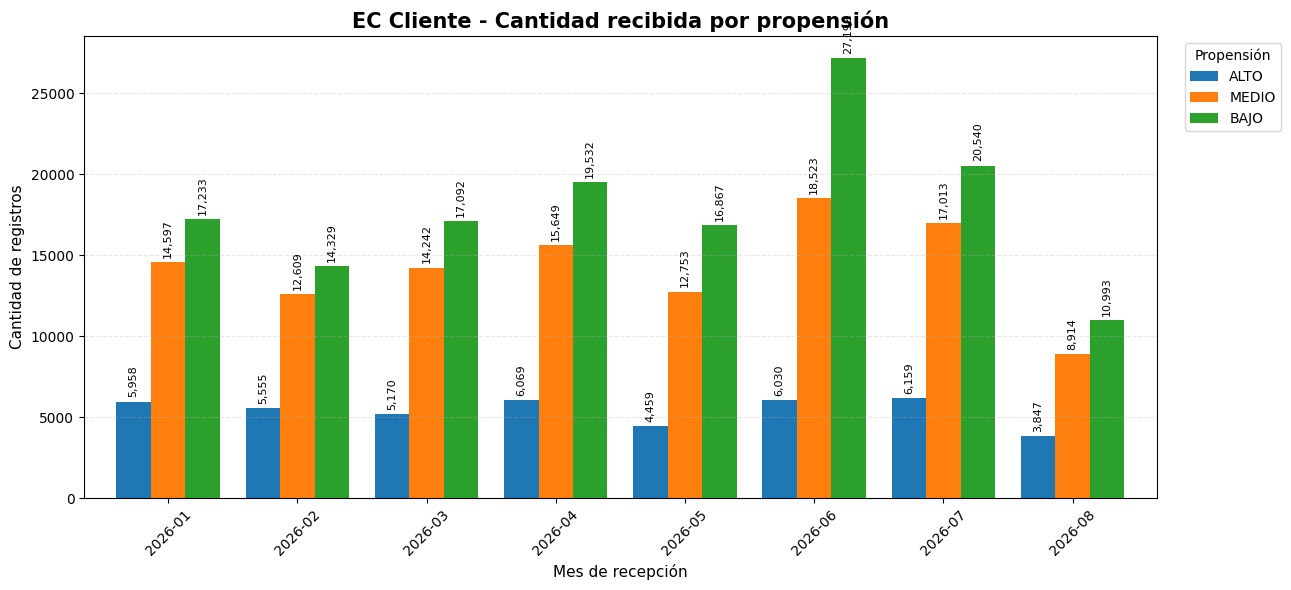

PROPENSION,ALTO,MEDIO,BAJO
mes,,,
2026-01-01,5958,14597,17233
2026-02-01,5555,12609,14329
2026-03-01,5170,14242,17092
2026-04-01,6069,15649,19532
2026-05-01,4459,12753,16867
2026-06-01,6030,18523,27199
2026-07-01,6159,17013,20540
2026-08-01,3847,8914,10993


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

# Reemplazar propensión nula
df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
)

# ============================================================
# CANTIDAD POR MES Y PROPENSIÓN
# ============================================================
df_propension = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Convertir a formato ancho
df_propension_pivot = (
    df_propension
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Orden deseado de las propensiones
orden_propension = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_propension_pivot.columns
]

# Agregar cualquier otra propensión que exista
otras_columnas = [
    columna
    for columna in df_propension_pivot.columns
    if columna not in columnas_existentes
]

columnas_grafico = columnas_existentes + otras_columnas

# ============================================================
# GRÁFICO DE BARRAS AGRUPADAS
# ============================================================
ax = df_propension_pivot[columnas_grafico].plot(
    kind="bar",
    figsize=(13, 6),
    width=0.80
)

# Colocar cantidades encima de las barras
for contenedor in ax.containers:
    etiquetas = [
        f"{barra.get_height():,.0f}"
        if barra.get_height() > 0
        else ""
        for barra in contenedor
    ]

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8,
        rotation=90
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Cantidad recibida por propensión",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Cantidad de registros", fontsize=11)

plt.xticks(
    range(len(df_propension_pivot.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_propension_pivot.index
    ],
    rotation=45
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# MOSTRAR TABLA UTILIZADA
# ============================================================
display(
    df_propension_pivot[columnas_grafico]
    .astype(int)
)

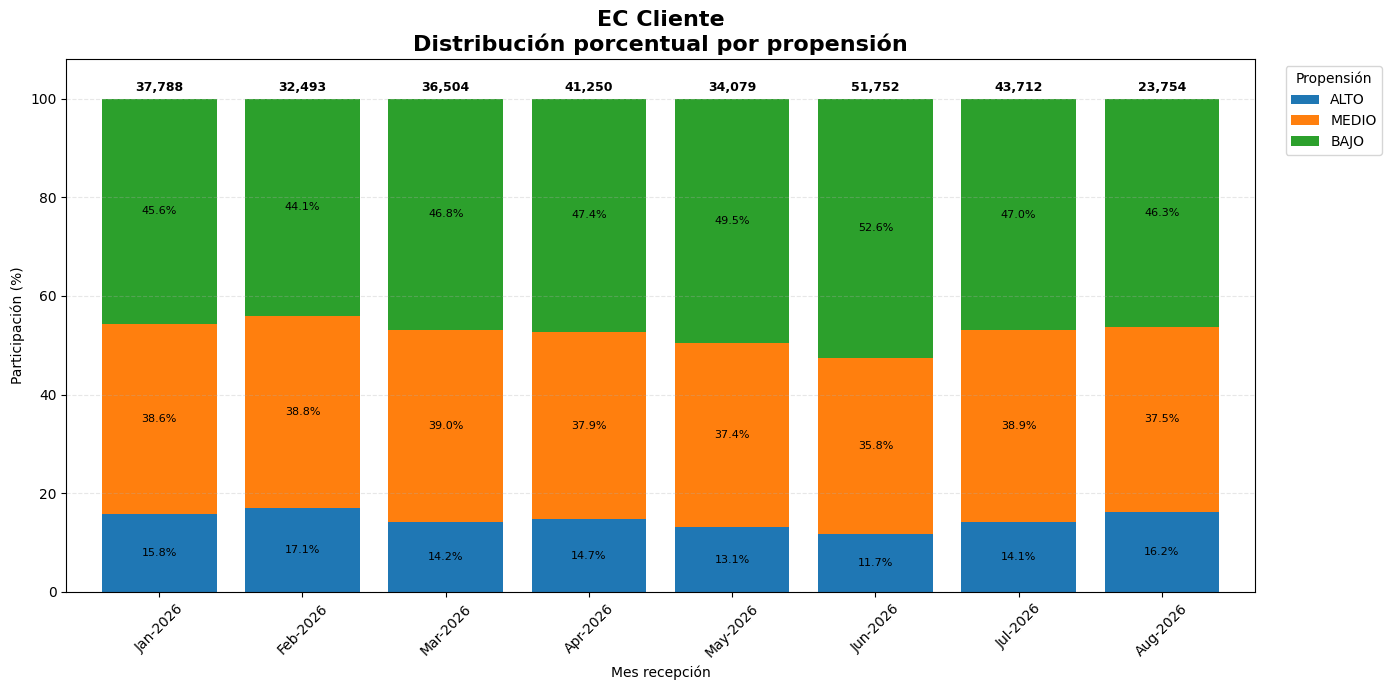

PROPENSION,ALTO,MEDIO,BAJO,Total Base
mes,,,,
2026-01-01,15.77%,38.63%,45.60%,37788
2026-02-01,17.10%,38.81%,44.10%,32493
2026-03-01,14.16%,39.01%,46.82%,36504
2026-04-01,14.71%,37.94%,47.35%,41250
2026-05-01,13.08%,37.42%,49.49%,34079
2026-06-01,11.65%,35.79%,52.56%,51752
2026-07-01,14.09%,38.92%,46.99%,43712
2026-08-01,16.20%,37.53%,46.28%,23754


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","PROPENSION"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"{producto_seleccionado}\nDistribución porcentual por propensión",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

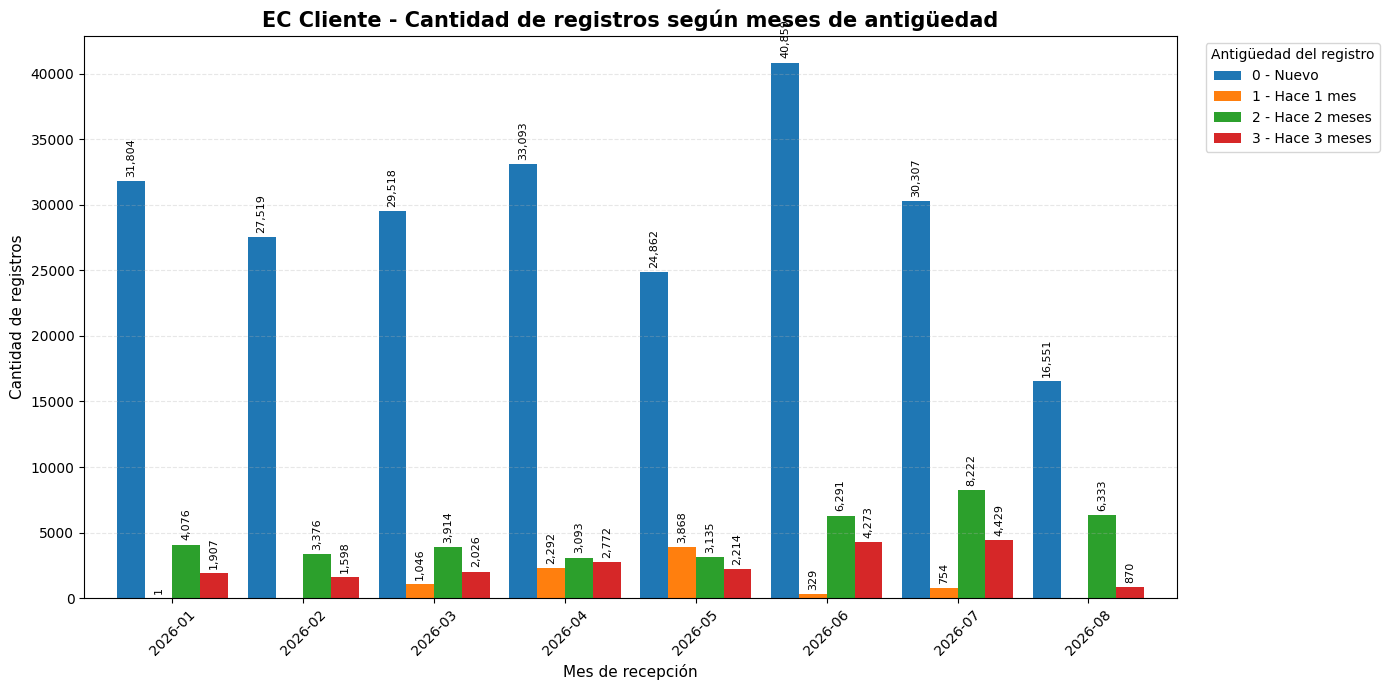

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses
mes,,,,
2026-01-01,31804,1,4076,1907
2026-02-01,27519,0,3376,1598
2026-03-01,29518,1046,3914,2026
2026-04-01,33093,2292,3093,2772
2026-05-01,24862,3868,3135,2214
2026-06-01,40859,329,6291,4273
2026-07-01,30307,754,8222,4429
2026-08-01,16551,0,6333,870


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["diferencia"] = pd.to_numeric(
    df_grafico["diferencia"],
    errors="coerce"
)

# Eliminar registros sin diferencia
df_grafico = df_grafico.dropna(subset=["mes", "diferencia"])

# Convertir diferencia a entero
df_grafico["diferencia"] = df_grafico["diferencia"].astype(int)

# ============================================================
# CREAR ETIQUETA DE ANTIGÜEDAD
# ============================================================
def crear_etiqueta_diferencia(valor):
    if valor == 0:
        return "0 - Nuevo"
    elif valor == 1:
        return "1 - Hace 1 mes"
    else:
        return f"{valor} - Hace {valor} meses"


df_grafico["antiguedad"] = df_grafico["diferencia"].apply(
    crear_etiqueta_diferencia
)

# ============================================================
# RESUMEN POR MES Y DIFERENCIA
# ============================================================
df_diferencia = (
    df_grafico
    .groupby(
        ["mes", "diferencia", "antiguedad"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Crear orden de las categorías según diferencia
orden_antiguedad = (
    df_diferencia[
        ["diferencia", "antiguedad"]
    ]
    .drop_duplicates()
    .sort_values("diferencia")["antiguedad"]
    .tolist()
)

# Convertir a formato ancho
df_diferencia_pivot = (
    df_diferencia
    .pivot(
        index="mes",
        columns="antiguedad",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Mantener orden lógico: nuevo, 1 mes, 2 meses, etc.
columnas_existentes = [
    columna
    for columna in orden_antiguedad
    if columna in df_diferencia_pivot.columns
]

df_diferencia_pivot = df_diferencia_pivot[
    columnas_existentes
]

# ============================================================
# GRÁFICO DE BARRAS AGRUPADAS
# ============================================================
ax = df_diferencia_pivot.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.85
)

# Agregar cantidades sobre cada barra
for contenedor in ax.containers:

    etiquetas = [
        f"{barra.get_height():,.0f}"
        if barra.get_height() > 0
        else ""
        for barra in contenedor
    ]

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8,
        rotation=90
    )

# ============================================================
# FORMATO DEL GRÁFICO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Cantidad de registros según meses de antigüedad",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mes de recepción",
    fontsize=11
)

plt.ylabel(
    "Cantidad de registros",
    fontsize=11
)

plt.xticks(
    range(len(df_diferencia_pivot.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_diferencia_pivot.index
    ],
    rotation=45
)

plt.legend(
    title="Antigüedad del registro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_diferencia_pivot.astype(int)
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

producto = "Reenganche EC"

df = df_filtrado[df_filtrado["producto"] == producto].copy()

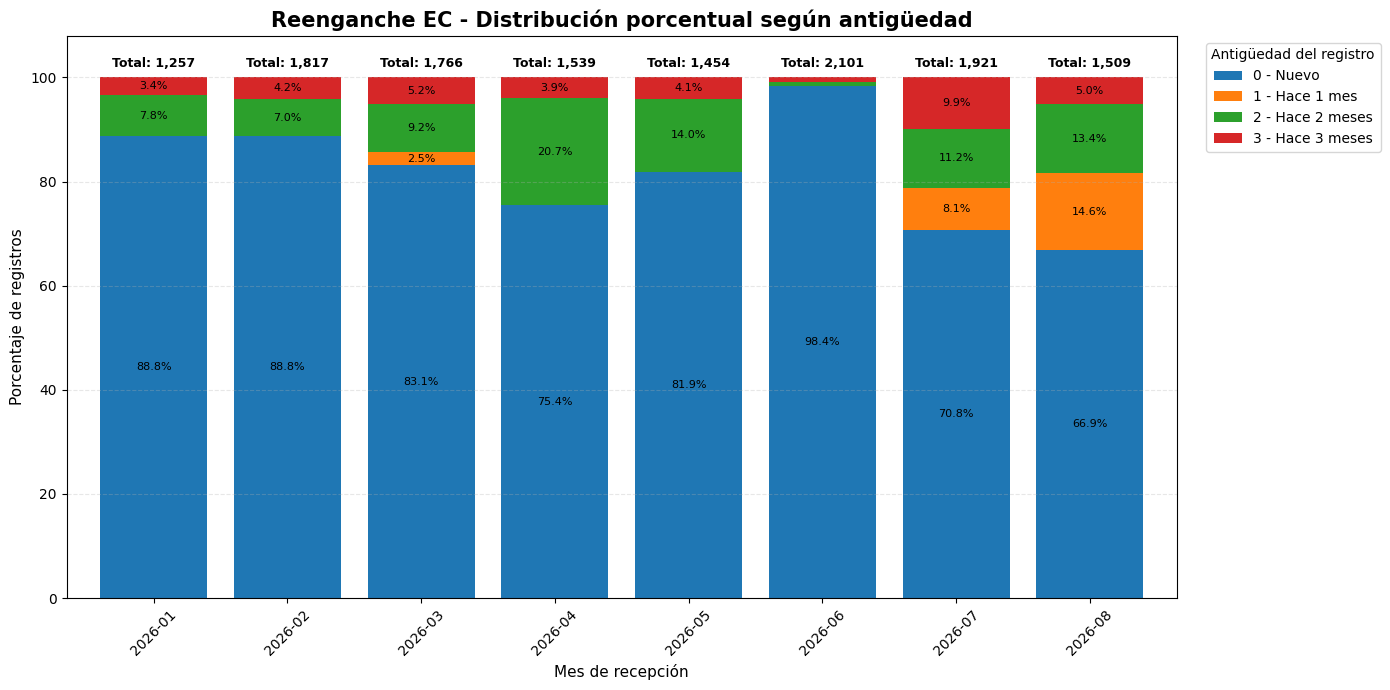

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,88.78%,0.00%,7.80%,3.42%,1257
2026-02-01,88.77%,0.00%,7.04%,4.18%,1817
2026-03-01,83.13%,2.49%,9.23%,5.15%,1766
2026-04-01,75.44%,0.00%,20.66%,3.90%,1539
2026-05-01,81.91%,0.00%,14.03%,4.06%,1454
2026-06-01,98.43%,0.00%,0.76%,0.81%,2101
2026-07-01,70.80%,8.07%,11.19%,9.94%,1921
2026-08-01,66.93%,14.65%,13.39%,5.04%,1509


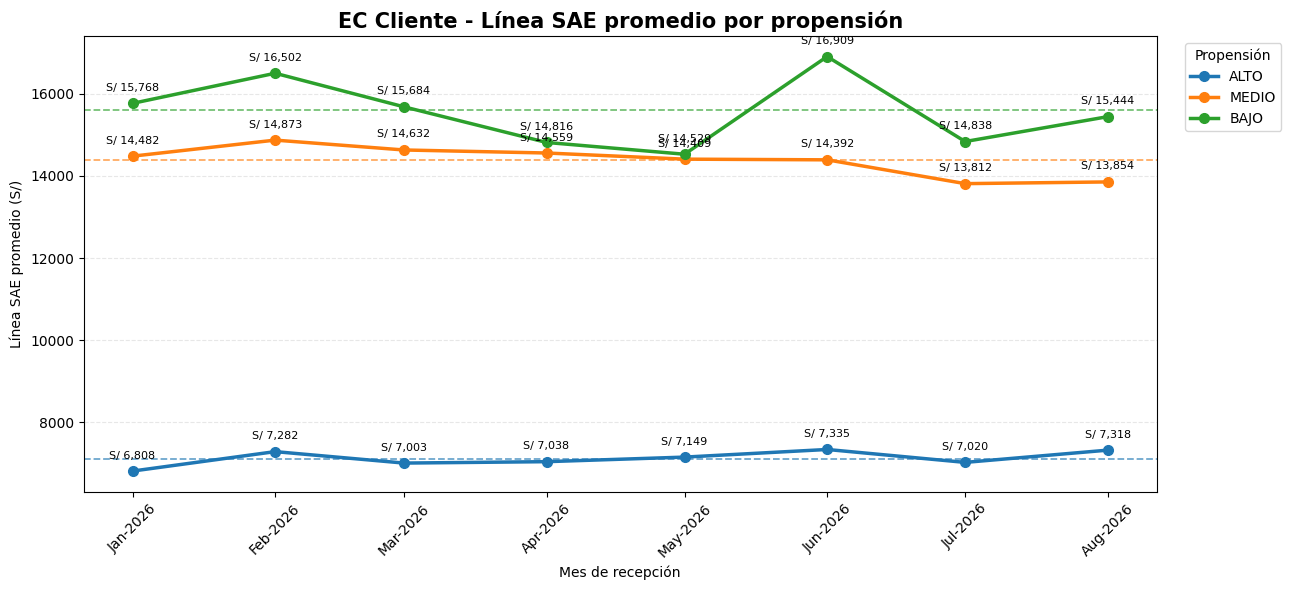

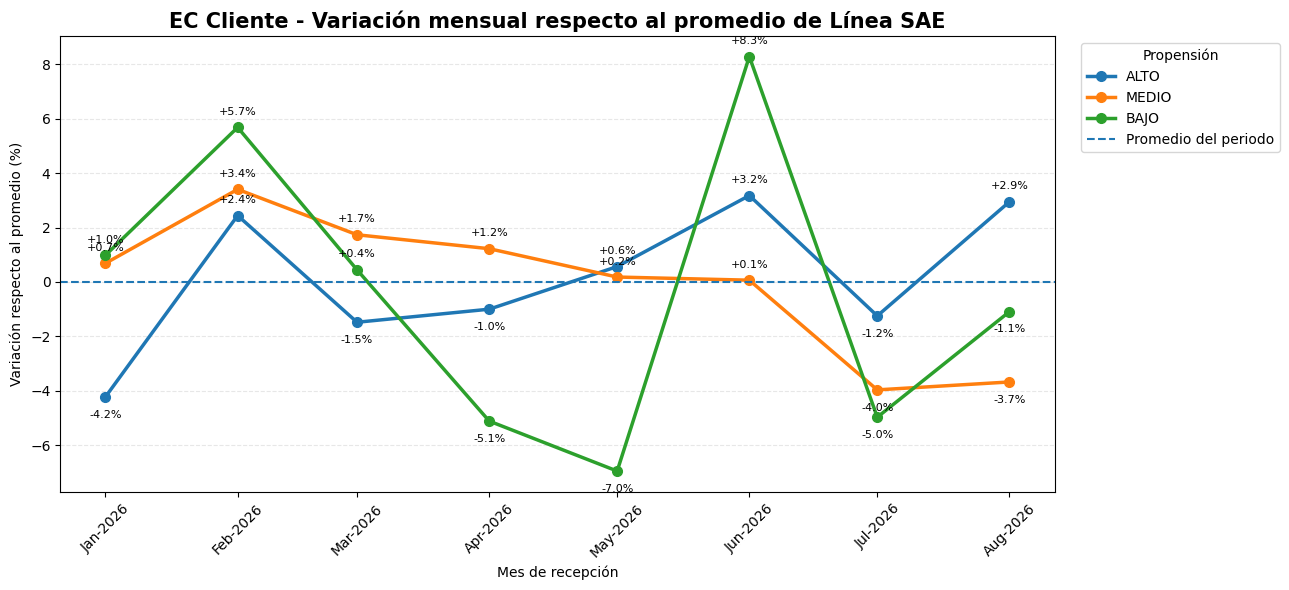

,Propensión,Promedio Línea SAE,Mínimo mensual,Máximo mensual,Desviación estándar,Coeficiente de variación,Rango respecto al promedio,Nivel de estabilidad
0,ALTO,"S/ 7,108.70","S/ 6,808.43","S/ 7,334.61",S/ 185.18,2.60%,7.40%,Muy estable
1,MEDIO,"S/ 14,382.94","S/ 13,812.19","S/ 14,872.77",S/ 368.17,2.56%,7.37%,Muy estable
2,BAJO,"S/ 15,614.66","S/ 14,528.82","S/ 16,908.71",S/ 838.11,5.37%,15.24%,Estable


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden deseado
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["linea_sae_sum"] = pd.to_numeric(
    df_grafico["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_grafico["linea_sae_count"] = pd.to_numeric(
    df_grafico["linea_sae_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar únicamente ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin observaciones de Línea SAE
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["linea_sae_count"] > 0)
].copy()

# ============================================================
# 2. PROMEDIO PONDERADO POR MES Y PROPENSIÓN
# ============================================================
df_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_mensual["Promedio_linea_sae"] = (
    df_mensual["linea_sae_sum"]
    / df_mensual["linea_sae_count"]
)

# Pasar a formato ancho
df_linea_sae = (
    df_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
    .sort_index()
)

# Mantener orden de las propensiones
columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_linea_sae.columns
]

df_linea_sae = df_linea_sae[columnas_existentes]

# ============================================================
# 3. PROMEDIO PONDERADO DEL PERIODO POR PROPENSIÓN
# ============================================================
df_periodo = (
    df_grafico
    .groupby("PROPENSION", as_index=False)
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_periodo["Promedio_periodo"] = (
    df_periodo["linea_sae_sum"]
    / df_periodo["linea_sae_count"]
)

promedios_periodo = (
    df_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN MENSUAL DE LA LÍNEA SAE PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_linea_sae.index,
        df_linea_sae[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Valores mensuales
    for mes, valor in df_linea_sae[propension].dropna().items():
        ax.annotate(
            f"S/ {valor:,.0f}",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Promedio del periodo: línea horizontal punteada
    promedio = promedios_periodo.get(propension)

    if pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - Línea SAE promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Línea SAE promedio (S/)")

ax.set_xticks(df_linea_sae.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_linea_sae.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. CALCULAR VARIACIÓN FRENTE AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion = df_linea_sae.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion[propension] = (
        (
            df_linea_sae[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN PORCENTUAL RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion.index,
        df_variacion[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion[propension].dropna().items():
        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, 9 if valor >= 0 else -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Línea central: promedio del periodo
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de Línea SAE",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Variación respecto al promedio (%)")

ax.set_xticks(df_variacion.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA RESUMEN DE ESTABILIDAD
# ============================================================
resumen_estabilidad = []

for propension in columnas_existentes:

    valores = df_linea_sae[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_porcentual = (
        (maximo - minimo) / promedio * 100
        if promedio != 0
        else 0
    )

    resumen_estabilidad.append({
        "Propensión": propension,
        "Promedio Línea SAE": promedio,
        "Mínimo mensual": minimo,
        "Máximo mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango respecto al promedio": rango_porcentual
    })

df_resumen_estabilidad = pd.DataFrame(resumen_estabilidad)

# Clasificación orientativa
df_resumen_estabilidad["Nivel de estabilidad"] = (
    df_resumen_estabilidad["Coeficiente de variación"]
    .apply(
        lambda x: (
            "Muy estable" if x < 5
            else "Estable" if x < 10
            else "Variable"
        )
    )
)

# Dar formato para mostrar
df_tabla_final = df_resumen_estabilidad.copy()

for columna in [
    "Promedio Línea SAE",
    "Mínimo mensual",
    "Máximo mensual",
    "Desviación estándar"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"S/ {x:,.2f}"
    )

for columna in [
    "Coeficiente de variación",
    "Rango respecto al promedio"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"{x:.2f}%"
    )

display(df_tabla_final)

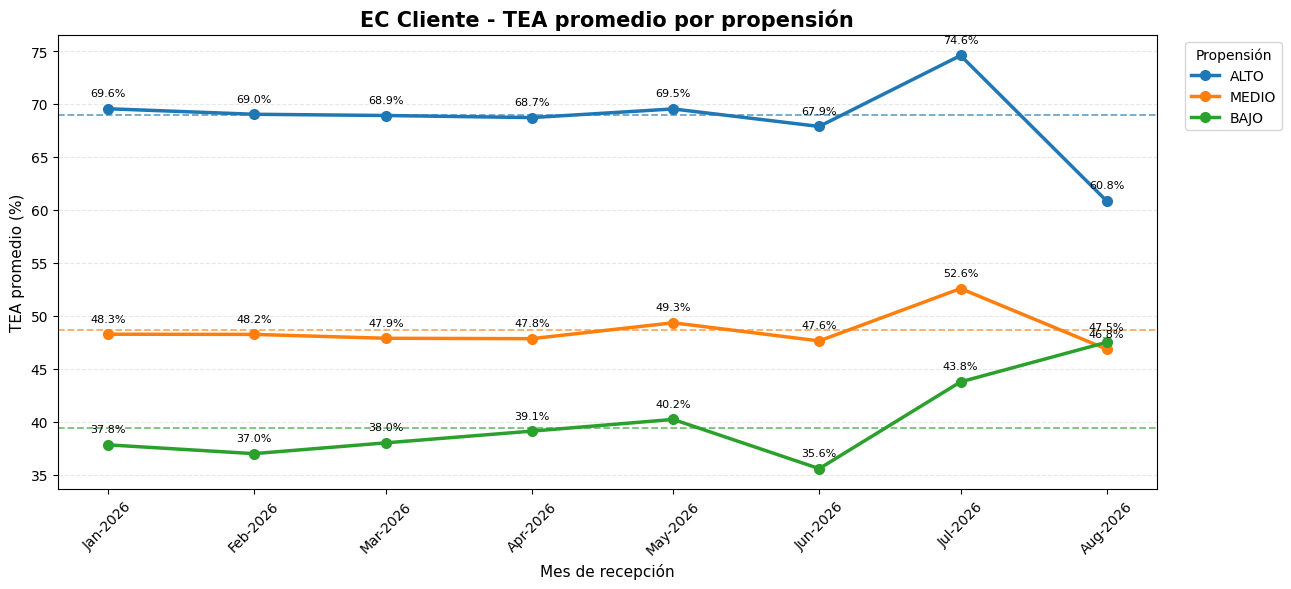

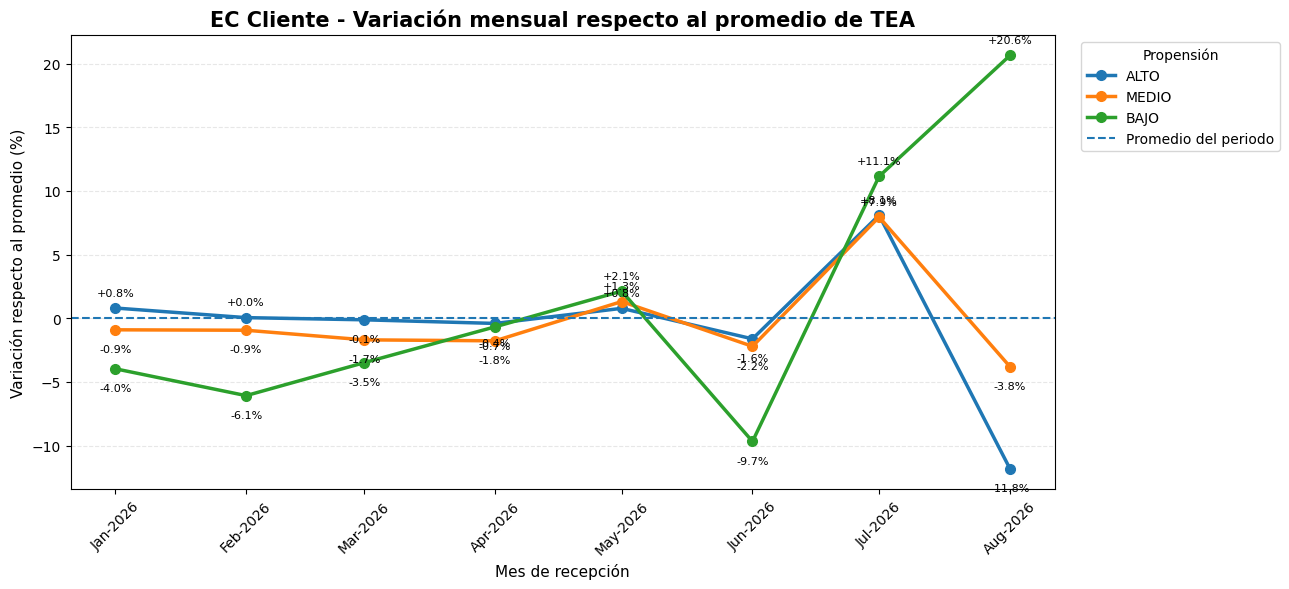

,Propensión,TEA promedio del periodo,TEA mínima mensual,TEA máxima mensual,Desviación estándar,Coeficiente de variación,Rango en puntos porcentuales,Nivel de estabilidad
0,ALTO,69.00%,60.85%,74.58%,3.75%,5.44%,13.73%,Estable
1,MEDIO,48.70%,46.85%,52.57%,1.76%,3.61%,5.72%,Muy estable
2,BAJO,39.37%,35.56%,47.49%,3.94%,10.01%,11.93%,Variable


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden de los segmentos
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["tea_sum"] = pd.to_numeric(
    df_grafico["tea_sum"],
    errors="coerce"
).fillna(0)

df_grafico["tea_count"] = pd.to_numeric(
    df_grafico["tea_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solo ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin datos válidos de TEA
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["tea_count"] > 0)
].copy()

# ============================================================
# 2. CALCULAR TEA PROMEDIO PONDERADA POR MES Y PROPENSIÓN
# ============================================================
df_tea_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# La TEA original está expresada como decimal:
# 0.6955 = 69.55 %
df_tea_mensual["Promedio_TEA"] = (
    df_tea_mensual["tea_sum"]
    / df_tea_mensual["tea_count"]
    * 100
)

# Formato ancho
df_tea = (
    df_tea_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
    .sort_index()
)

columnas_existentes = [
    propension
    for propension in orden_propension
    if propension in df_tea.columns
]

df_tea = df_tea[columnas_existentes]

# ============================================================
# 3. TEA PROMEDIO PONDERADA DEL PERIODO POR PROPENSIÓN
# ============================================================
df_tea_periodo = (
    df_grafico
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

df_tea_periodo["Promedio_periodo"] = (
    df_tea_periodo["tea_sum"]
    / df_tea_periodo["tea_count"]
    * 100
)

promedios_periodo = (
    df_tea_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN DE LA TEA PROMEDIO POR PROPENSIÓN
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_tea.index,
        df_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Etiquetas mensuales
    for mes, valor in df_tea[propension].dropna().items():
        ax.annotate(
            f"{valor:.1f}%",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Línea punteada: promedio del periodo
    promedio = promedios_periodo.get(propension)

    if promedio is not None and pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - TEA promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "TEA promedio (%)",
    fontsize=11
)

ax.set_xticks(df_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. VARIACIÓN MENSUAL RESPECTO AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion_tea = df_tea.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion_tea[propension] = (
        (
            df_tea[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN DE LA TEA RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion_tea.index,
        df_variacion_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion_tea[propension].dropna().items():

        desplazamiento = 9 if valor >= 0 else -16

        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, desplazamiento),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Referencia central
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de TEA",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "Variación respecto al promedio (%)",
    fontsize=11
)

ax.set_xticks(df_variacion_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA DE ESTABILIDAD DE LA TEA
# ============================================================
resumen_estabilidad_tea = []

for propension in columnas_existentes:

    valores = df_tea[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_puntos_porcentuales = maximo - minimo

    resumen_estabilidad_tea.append({
        "Propensión": propension,
        "TEA promedio del periodo": promedio,
        "TEA mínima mensual": minimo,
        "TEA máxima mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango en puntos porcentuales": rango_puntos_porcentuales
    })

df_resumen_tea = pd.DataFrame(
    resumen_estabilidad_tea
)

# Clasificación orientativa
df_resumen_tea["Nivel de estabilidad"] = (
    df_resumen_tea["Coeficiente de variación"]
    .apply(
        lambda valor: (
            "Muy estable"
            if valor < 5
            else "Estable"
            if valor < 10
            else "Variable"
        )
    )
)

# ============================================================
# 8. FORMATO DE LA TABLA FINAL
# ============================================================
df_tabla_tea = df_resumen_tea.copy()

for columna in [
    "TEA promedio del periodo",
    "TEA mínima mensual",
    "TEA máxima mensual",
    "Desviación estándar",
    "Coeficiente de variación",
    "Rango en puntos porcentuales"
]:
    df_tabla_tea[columna] = (
        df_tabla_tea[columna]
        .map(lambda valor: f"{valor:.2f}%")
    )

display(df_tabla_tea)

In [ ]:
df_filtrado = df_resumen.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'cenvo_repitencia.xlsx')

df_filtrado.to_excel(ruta_archivo, index=False)


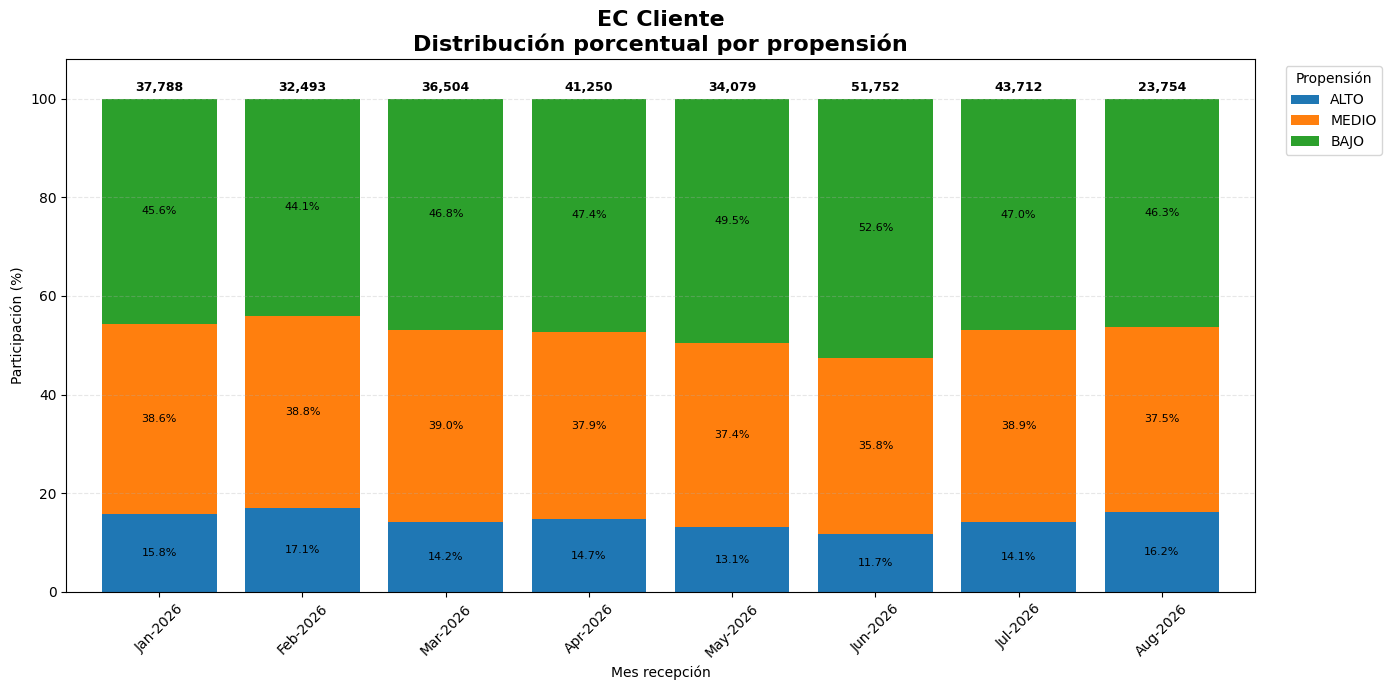

PROPENSION,ALTO,MEDIO,BAJO,Total Base
mes,,,,
2026-01-01,15.77%,38.63%,45.60%,37788
2026-02-01,17.10%,38.81%,44.10%,32493
2026-03-01,14.16%,39.01%,46.82%,36504
2026-04-01,14.71%,37.94%,47.35%,41250
2026-05-01,13.08%,37.42%,49.49%,34079
2026-06-01,11.65%,35.79%,52.56%,51752
2026-07-01,14.09%,38.92%,46.99%,43712
2026-08-01,16.20%,37.53%,46.28%,23754


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","PROPENSION"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"{producto_seleccionado}\nDistribución porcentual por propensión",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

In [61]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# Orden de presentación
orden_propension = ['1','2','3','4','5','6','7','8','9','10']

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Convertir mes
df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

# Convertir columnas numéricas
columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Limpiar propensión
df_tabla["PROPENSION"] = (
    df_tabla["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solamente ALTO, MEDIO y BAJO
df_tabla = df_tabla[
    df_tabla["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar filas sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR POR MES Y PROPENSIÓN
# ============================================================
df_resumen = (
    df_tabla
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen["Promedio_linea_sae"] = np.where(
    df_resumen["linea_sae_count"] > 0,
    df_resumen["linea_sae_sum"]
    / df_resumen["linea_sae_count"],
    np.nan
)

# La TEA está almacenada como decimal:
# 0.6955 equivale a 69.55 %
df_resumen["Promedio_TEA"] = np.where(
    df_resumen["tea_count"] > 0,
    (
        df_resumen["tea_sum"]
        / df_resumen["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. TOTAL DE LA BASE POR MES
# ============================================================
df_total_mes = (
    df_resumen
    .groupby("mes", as_index=False)["cantidad"]
    .sum()
    .rename(
        columns={
            "cantidad": "Total Base"
        }
    )
)

df_resumen = df_resumen.merge(
    df_total_mes,
    on="mes",
    how="left"
)

# Participación de cada propensión dentro del mes
df_resumen["Participacion"] = np.where(
    df_resumen["Total Base"] > 0,
    (
        df_resumen["cantidad"]
        / df_resumen["Total Base"]
    ) * 100,
    0
)

# ============================================================
# 5. CREAR TABLAS PIVOT
# ============================================================

# Participación porcentual
tabla_participacion = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Participacion"
    )
)

# Línea SAE promedio
tabla_linea_sae = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
)

# TEA promedio
tabla_tea = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
)

# Cantidad por propensión
tabla_cantidad = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="cantidad"
    )
)

# Asegurar que las columnas estén en orden
for propension in orden_propension:

    if propension not in tabla_participacion.columns:
        tabla_participacion[propension] = 0

    if propension not in tabla_linea_sae.columns:
        tabla_linea_sae[propension] = np.nan

    if propension not in tabla_tea.columns:
        tabla_tea[propension] = np.nan

    if propension not in tabla_cantidad.columns:
        tabla_cantidad[propension] = 0

tabla_participacion = tabla_participacion[orden_propension]
tabla_linea_sae = tabla_linea_sae[orden_propension]
tabla_tea = tabla_tea[orden_propension]
tabla_cantidad = tabla_cantidad[orden_propension]

# ============================================================
# 6. ARMAR TABLA FINAL
# ============================================================
df_tabla_final = pd.DataFrame(
    index=tabla_participacion.index
)

# Total mensual
df_tabla_final["Total Base"] = (
    tabla_cantidad.sum(axis=1)
)

# Columnas por propensión
for propension in orden_propension:

    df_tabla_final[
        f"% {propension}"
    ] = tabla_participacion[propension]

    df_tabla_final[
        f"Línea SAE {propension}"
    ] = tabla_linea_sae[propension]

    df_tabla_final[
        f"TEA {propension}"
    ] = tabla_tea[propension]

# ============================================================
# 7. FILA CONSOLIDADA DEL PERIODO
# ============================================================
df_periodo = (
    df_tabla
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

total_periodo = df_periodo["cantidad"].sum()

fila_periodo = {
    "Total Base": total_periodo
}

for propension in orden_propension:

    datos = df_periodo[
        df_periodo["PROPENSION"] == propension
    ]

    if not datos.empty:

        cantidad_propension = datos["cantidad"].iloc[0]

        participacion = (
            cantidad_propension / total_periodo * 100
            if total_periodo > 0
            else 0
        )

        promedio_linea = (
            datos["linea_sae_sum"].iloc[0]
            / datos["linea_sae_count"].iloc[0]
            if datos["linea_sae_count"].iloc[0] > 0
            else np.nan
        )

        promedio_tea = (
            datos["tea_sum"].iloc[0]
            / datos["tea_count"].iloc[0]
            * 100
            if datos["tea_count"].iloc[0] > 0
            else np.nan
        )

    else:

        participacion = 0
        promedio_linea = np.nan
        promedio_tea = np.nan

    fila_periodo[f"% {propension}"] = participacion
    fila_periodo[f"Línea SAE {propension}"] = promedio_linea
    fila_periodo[f"TEA {propension}"] = promedio_tea

# Cambiar el índice mensual a texto
df_tabla_final.index = [
    fecha.strftime("%B %Y").capitalize()
    for fecha in df_tabla_final.index
]

# Agregar fila consolidada
df_tabla_final.loc["TOTAL PERIODO"] = fila_periodo

# ============================================================
# 8. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

# Total base como entero con separador de miles
df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

for propension in orden_propension:

    # Participación
    df_tabla_mostrar[f"% {propension}"] = (
        df_tabla_mostrar[f"% {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

    # Línea SAE
    df_tabla_mostrar[f"Línea SAE {propension}"] = (
        df_tabla_mostrar[f"Línea SAE {propension}"]
        .map(
            lambda valor:
            f"S/ {valor:,.2f}"
            if pd.notna(valor)
            else "-"
        )
    )

    # TEA
    df_tabla_mostrar[f"TEA {propension}"] = (
        df_tabla_mostrar[f"TEA {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

# Nombre del índice
df_tabla_mostrar.index.name = "Mes de recepción"

# ============================================================
# 9. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Total Base,% 1,Línea SAE 1,TEA 1,% 2,Línea SAE 2,TEA 2,% 3,Línea SAE 3,TEA 3,...,TEA 7,% 8,Línea SAE 8,TEA 8,% 9,Línea SAE 9,TEA 9,% 10,Línea SAE 10,TEA 10
Mes de recepción,,,,,,,,,,,,,,,,,,,,,
January 2026,"1,257",64.04%,"S/ 12,911.30",46.19%,22.04%,"S/ 15,025.63",35.57%,7.16%,"S/ 17,538.89",30.77%,...,-,-,-,-,-,-,-,-,-,-
February 2026,"1,817",67.47%,"S/ 13,092.90",46.82%,18.82%,"S/ 14,777.19",35.13%,7.82%,"S/ 17,200.70",32.18%,...,20.90%,0.06%,"S/ 6,700.00",39.90%,-,-,-,-,-,-
March 2026,"1,766",65.18%,"S/ 12,855.87",39.90%,21.18%,"S/ 15,488.50",-,7.47%,"S/ 17,337.88",-,...,-,0.06%,"S/ 19,200.00",-,-,-,-,-,-,-
April 2026,"1,539",65.63%,"S/ 13,165.94",46.09%,20.27%,"S/ 15,110.26",35.83%,8.32%,"S/ 18,703.12",31.32%,...,27.90%,-,-,-,-,-,-,-,-,-
May 2026,"1,454",66.51%,"S/ 13,053.36",47.64%,19.39%,"S/ 14,502.13",37.56%,7.63%,"S/ 16,957.66",31.34%,...,20.90%,0.14%,"S/ 20,000.00",10.45%,-,-,-,0.07%,"S/ 20,100.00",20.90%
June 2026,"2,101",38.32%,"S/ 13,932.92",41.33%,17.71%,"S/ 14,938.44",34.79%,37.55%,"S/ 15,231.94",39.65%,...,27.90%,0.10%,"S/ 20,850.00",27.90%,0.05%,"S/ 25,000.00",20.90%,0.05%,"S/ 11,600.00",20.90%
July 2026,"1,921",52.42%,"S/ 13,614.70",40.68%,27.49%,"S/ 15,025.00",34.11%,11.19%,"S/ 17,090.23",31.55%,...,21.70%,0.10%,"S/ 23,500.00",20.90%,0.05%,"S/ 25,000.00",20.90%,-,-,-
August 2026,"1,509",56.20%,"S/ 12,739.74",43.74%,26.64%,"S/ 15,197.76",34.66%,9.21%,"S/ 16,226.62",30.68%,...,14.45%,-,-,-,-,-,-,-,-,-
TOTAL PERIODO,"13,364",58.51%,"S/ 13,159.24",44.77%,21.62%,"S/ 15,026.79",35.20%,13.06%,"S/ 16,342.38",35.42%,...,21.30%,0.06%,"S/ 19,325.00",22.63%,0.01%,"S/ 25,000.00",20.90%,0.01%,"S/ 15,850.00",20.90%


In [62]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Eliminar registros sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR SOLAMENTE POR MES
# No se considera PROPENSION
# ============================================================
df_resumen_mensual = (
    df_tabla
    .groupby(
        "mes",
        as_index=False
    )
    .agg(
        total_base=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
    .sort_values("mes")
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen_mensual["Promedio Línea SAE"] = np.where(
    df_resumen_mensual["linea_sae_count"] > 0,
    (
        df_resumen_mensual["linea_sae_sum"]
        / df_resumen_mensual["linea_sae_count"]
    ),
    np.nan
)

# TEA almacenada como decimal:
# 0.50 equivale a 50 %
df_resumen_mensual["Promedio TEA"] = np.where(
    df_resumen_mensual["tea_count"] > 0,
    (
        df_resumen_mensual["tea_sum"]
        / df_resumen_mensual["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. SELECCIONAR COLUMNAS FINALES
# ============================================================
df_tabla_final = df_resumen_mensual[
    [
        "mes",
        "total_base",
        "Promedio Línea SAE",
        "Promedio TEA"
    ]
].copy()

df_tabla_final = df_tabla_final.rename(
    columns={
        "mes": "Mes de recepción",
        "total_base": "Total Base"
    }
)

# ============================================================
# 5. FILA TOTAL DEL PERIODO
# ============================================================
total_base_periodo = df_tabla["cantidad"].sum()

total_linea_sum = df_tabla["linea_sae_sum"].sum()
total_linea_count = df_tabla["linea_sae_count"].sum()

total_tea_sum = df_tabla["tea_sum"].sum()
total_tea_count = df_tabla["tea_count"].sum()

promedio_linea_periodo = (
    total_linea_sum / total_linea_count
    if total_linea_count > 0
    else np.nan
)

promedio_tea_periodo = (
    total_tea_sum / total_tea_count * 100
    if total_tea_count > 0
    else np.nan
)

fila_total = pd.DataFrame({
    "Mes de recepción": ["TOTAL PERIODO"],
    "Total Base": [total_base_periodo],
    "Promedio Línea SAE": [promedio_linea_periodo],
    "Promedio TEA": [promedio_tea_periodo]
})

# Convertir meses a texto antes de concatenar
df_tabla_final["Mes de recepción"] = (
    df_tabla_final["Mes de recepción"]
    .dt.strftime("%B %Y")
    .str.capitalize()
)

df_tabla_final = pd.concat(
    [
        df_tabla_final,
        fila_total
    ],
    ignore_index=True
)

# ============================================================
# 6. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

df_tabla_mostrar["Promedio Línea SAE"] = (
    df_tabla_mostrar["Promedio Línea SAE"]
    .map(
        lambda valor:
        f"S/ {valor:,.2f}"
        if pd.notna(valor)
        else "-"
    )
)

df_tabla_mostrar["Promedio TEA"] = (
    df_tabla_mostrar["Promedio TEA"]
    .map(
        lambda valor:
        f"{valor:.2f}%"
        if pd.notna(valor)
        else "-"
    )
)

# ============================================================
# 7. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Mes de recepción,Total Base,Promedio Línea SAE,Promedio TEA
0,January 2026,"1,257","S/ 14,178.28",41.47%
1,February 2026,"1,817","S/ 14,100.28",42.40%
2,March 2026,"1,766","S/ 14,241.79",39.90%
3,April 2026,"1,539","S/ 14,325.86",41.74%
4,May 2026,"1,454","S/ 14,129.09",43.19%
5,June 2026,"2,101","S/ 15,002.86",38.64%
6,July 2026,"1,921","S/ 14,944.14",36.71%
7,August 2026,"1,509","S/ 14,375.28",38.56%
8,TOTAL PERIODO,"13,364","S/ 14,449.68",40.19%
